# Sensor Timestep Importance Analysis

## Objective
This notebook identifies **which of the 10 timesteps** in a fixed sensor cycle is most informative for predicting a risk level (0 = No Risk, 1 = Low, 2 = Medium, 3 = Catastrophic).

We use two complementary approaches:
1. **Attention-based interpretability** — a Transformer model learns to weight timesteps via self-attention
2. **Leave-one-timestep-out ablation** — we zero out each timestep and measure the performance drop

---

## SECTION 1: Setup
Import libraries, set seeds, and detect hardware.

In [ ]:
# ── Standard library ──────────────────────────────────────────────────────────
import os
import random
import warnings
warnings.filterwarnings('ignore')

# ── Numerical / data ──────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
from collections import Counter

# ── Plotting ──────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── Sklearn ───────────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)
from scipy.stats import spearmanr, pearsonr

# ── PyTorch ───────────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# ── Device ────────────────────────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device : {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU name     : {torch.cuda.get_device_name(0)}')
    print(f'GPU memory   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

# ── Plot style ────────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120, 'savefig.dpi': 150,
                     'figure.figsize': (9, 5)})

print('\nAll libraries loaded successfully.')

Using device : cuda
GPU name     : Tesla T4
GPU memory   : 15.6 GB

All libraries loaded successfully.


## SECTION 2: Data Loading

### File format (confirmed from sample data)
Each line is **comma-separated** with exactly **27 fields**:
```
sample_id, timepoint, f1, f2, ..., f25
```
After every **10 sensor rows** there is a **standalone integer line** (the risk label: 0–3).
There are no blank separator lines. Block size = **11 lines**.

The parser below handles this exactly.

In [ ]:
# ── USER: set the path to your train.txt here ───────────────────────────────
DATA_PATH = 'train.txt'   # e.g. '/content/train.txt' after uploading to Colab

# ── Dataset constants ────────────────────────────────────────────────────────
NUM_TIMESTEPS = 10
NUM_FEATURES  = 25   # columns 2..26 of each sensor row (0-indexed)
NUM_CLASSES   = 4
CLASS_NAMES   = ['No Risk', 'Low Risk', 'Medium Risk', 'Catastrophic']


def load_dataset(path: str):
    """
    Parse the sensor-cycle risk dataset.

    Format (comma-separated, no blank lines):
      10 x  sample_id, timepoint, f1, f2, ..., f25   <- sensor rows
      1  x  risk_label                                <- integer 0-3
      ... repeated for every sample

    Returns
    -------
    X : np.ndarray  shape (N, 10, 25)  – normalised sensor readings
    y : np.ndarray  shape (N,)         – integer risk labels
    """
    X_list, y_list = [], []
    skipped = 0

    with open(path, 'r') as fh:
        # Keep ALL non-empty lines; do NOT strip blank lines differently –
        # there are none, but strip() handles \n / \r\n cleanly.
        lines = [ln.strip() for ln in fh if ln.strip()]

    BLOCK = NUM_TIMESTEPS + 1          # 11 lines per sample
    num_blocks = len(lines) // BLOCK
    remainder  = len(lines) %  BLOCK

    print(f'Total non-empty lines : {len(lines)}')
    print(f'Expected block size   : {BLOCK}  (10 sensor + 1 label)')
    print(f'Complete blocks found : {num_blocks}  |  trailing lines: {remainder}')

    for b in range(num_blocks):
        start = b * BLOCK
        block = lines[start : start + BLOCK]

        # ── Label line (last line of block) ──────────────────────────────────
        # It is a single integer with no comma.
        label_str = block[-1]
        try:
            label = int(label_str)
            assert 0 <= label < NUM_CLASSES, f'label {label} out of range'
        except Exception as e:
            if b < 5 or b % 5000 == 0:
                print(f'[WARN] Block {b}: bad label "{label_str}" ({e}) — skipping.')
            skipped += 1
            continue

        # ── Sensor rows (first 10 lines of block) ─────────────────────────
        ok = True
        timesteps = []
        for t in range(NUM_TIMESTEPS):
            # Split on comma; expected tokens: sample_id, timepoint, f1..f25
            tokens = block[t].split(',')
            if len(tokens) < 2 + NUM_FEATURES:
                if b < 5:
                    print(f'[WARN] Block {b}, timestep {t}: '
                          f'only {len(tokens)} comma-separated tokens — skipping block.')
                ok = False
                break
            try:
                # Columns 0 = sample_id, 1 = timepoint, 2..26 = features
                features = [float(v) for v in tokens[2 : 2 + NUM_FEATURES]]
            except ValueError as e:
                if b < 5:
                    print(f'[WARN] Block {b}, timestep {t}: float parse error ({e}) — skipping.')
                ok = False
                break
            timesteps.append(features)

        if not ok:
            skipped += 1
            continue

        X_list.append(timesteps)
        y_list.append(label)

    X = np.array(X_list, dtype=np.float32)   # (N, 10, 25)
    y = np.array(y_list, dtype=np.int64)      # (N,)

    print(f'\nResult : {len(X_list)} valid samples  |  {skipped} skipped blocks')
    return X, y


# ── Load ─────────────────────────────────────────────────────────────────────
X, y = load_dataset(DATA_PATH)

if len(X) == 0:
    raise RuntimeError(
        'Parsed 0 samples. Check DATA_PATH and that the file uses comma separators.'
    )

# ── Summary ──────────────────────────────────────────────────────────────────
from collections import Counter
counts = Counter(y.tolist())

print(f'\nX shape : {X.shape}   (samples x timesteps x features)')
print(f'y shape : {y.shape}')
print('\nClass distribution:')
for cls in range(NUM_CLASSES):
    n = counts.get(cls, 0)
    print(f'  {cls}  {CLASS_NAMES[cls]:15s}: {n:6d}  ({100*n/len(y):.1f}%)')
print('\nExample – first sample, timestep 0, first 5 features:')
print(X[0, 0, :5])
print(f'\nFeature range: min={X.min():.4f}  max={X.max():.4f}')


Total non-empty lines : 440000
Expected block size   : 11  (10 sensor + 1 label)
Complete blocks found : 40000  |  trailing lines: 0

Result : 40000 valid samples  |  0 skipped blocks

X shape : (40000, 10, 25)   (samples x timesteps x features)
y shape : (40000,)

Class distribution:
  0  No Risk        :  10599  (26.5%)
  1  Low Risk       :   8117  (20.3%)
  2  Medium Risk    :   8977  (22.4%)
  3  Catastrophic   :  12307  (30.8%)

Example – first sample, timestep 0, first 5 features:
[0.1097 0.6296 0.1322 0.7968 0.7564]

Feature range: min=0.0000  max=1.0000


## SECTION 3: Exploratory Data Analysis

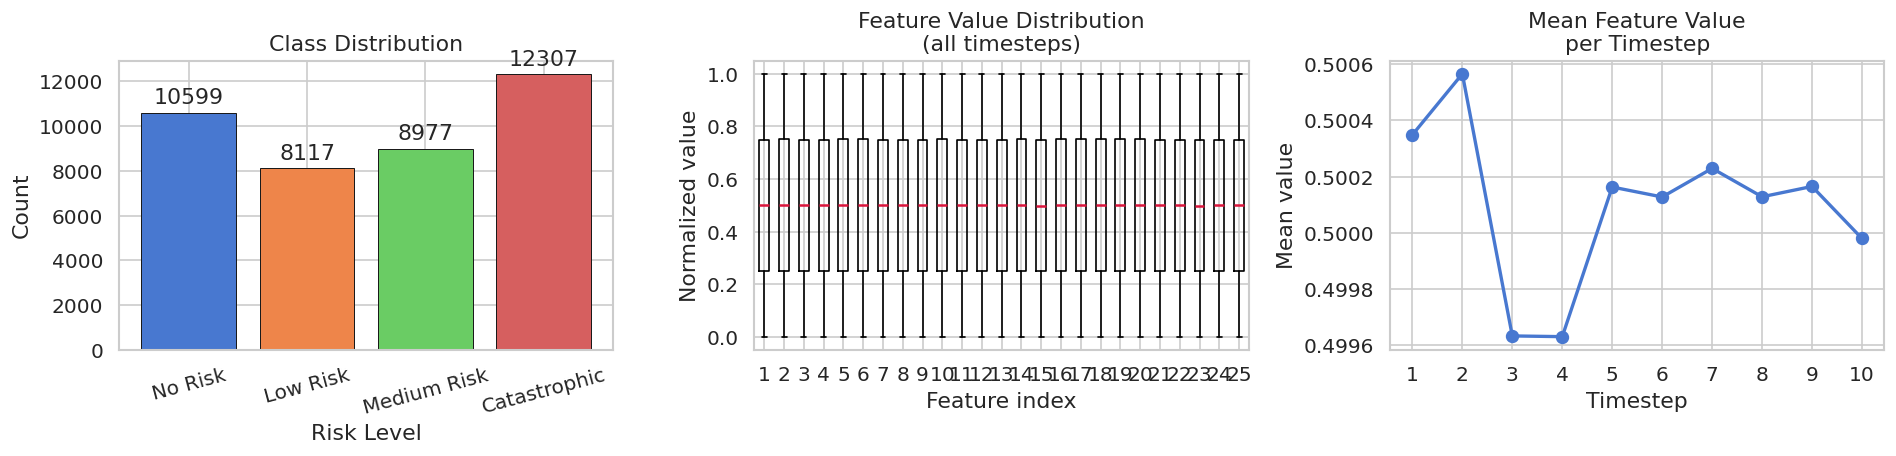

NaN values in X: 0

Feature statistics (over all timesteps and samples):
        count      mean       std  min       25%     50%       75%  max
F1   400000.0  0.500057  0.288633  0.0  0.250300  0.5003  0.749900  1.0
F2   400000.0  0.500003  0.288667  0.0  0.250100  0.4993  0.750400  1.0
F3   400000.0  0.499717  0.288959  0.0  0.248800  0.5001  0.749900  1.0
F4   400000.0  0.499881  0.288613  0.0  0.250300  0.5003  0.749400  1.0
F5   400000.0  0.500389  0.288740  0.0  0.250700  0.4998  0.750300  1.0
F6   400000.0  0.500328  0.288677  0.0  0.250700  0.5000  0.750500  1.0
F7   400000.0  0.499966  0.288763  0.0  0.250200  0.4996  0.750200  1.0
F8   400000.0  0.499638  0.288586  0.0  0.249500  0.4994  0.749400  1.0
F9   400000.0  0.499797  0.288265  0.0  0.250100  0.4999  0.748800  1.0
F10  400000.0  0.500351  0.288983  0.0  0.249475  0.5010  0.750700  1.0
F11  400000.0  0.499920  0.288914  0.0  0.249100  0.4999  0.750200  1.0
F12  400000.0  0.500829  0.288471  0.0  0.251100  0.5019  0.750

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# ── 3a. Class distribution ────────────────────────────────────────────────────
ax = axes[0]
vals = [counts.get(c, 0) for c in range(NUM_CLASSES)]
bars = ax.bar(CLASS_NAMES, vals,
              color=sns.color_palette('muted', NUM_CLASSES), edgecolor='k', linewidth=0.6)
ax.bar_label(bars, fmt='%d', padding=3)
ax.set_title('Class Distribution')
ax.set_xlabel('Risk Level')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=15)

# ── 3b. Feature value distribution (global) ────────────────────────────────────
ax = axes[1]
flat = X.reshape(-1, NUM_FEATURES)    # (N*10, 25)
ax.boxplot(flat, showfliers=False,
           medianprops=dict(color='crimson', linewidth=1.5))
ax.set_title('Feature Value Distribution\n(all timesteps)')
ax.set_xlabel('Feature index')
ax.set_ylabel('Normalized value')

# ── 3c. Mean sensor value per timestep ────────────────────────────────────────
ax = axes[2]
mean_per_ts = X.mean(axis=(0, 2))     # (10,)
ax.plot(range(1, 11), mean_per_ts, marker='o', linewidth=2, markersize=7)
ax.set_xticks(range(1, 11))
ax.set_title('Mean Feature Value\nper Timestep')
ax.set_xlabel('Timestep')
ax.set_ylabel('Mean value')

plt.tight_layout()
plt.savefig('eda_overview.png', bbox_inches='tight')
plt.show()

# ── Missing values ────────────────────────────────────────────────────────────
nan_count = np.isnan(X).sum()
print(f'NaN values in X: {nan_count}')

# ── Feature statistics ────────────────────────────────────────────────────────
stats_df = pd.DataFrame(
    flat,
    columns=[f'F{i+1}' for i in range(NUM_FEATURES)]
).describe().T
print('\nFeature statistics (over all timesteps and samples):')
print(stats_df.to_string())

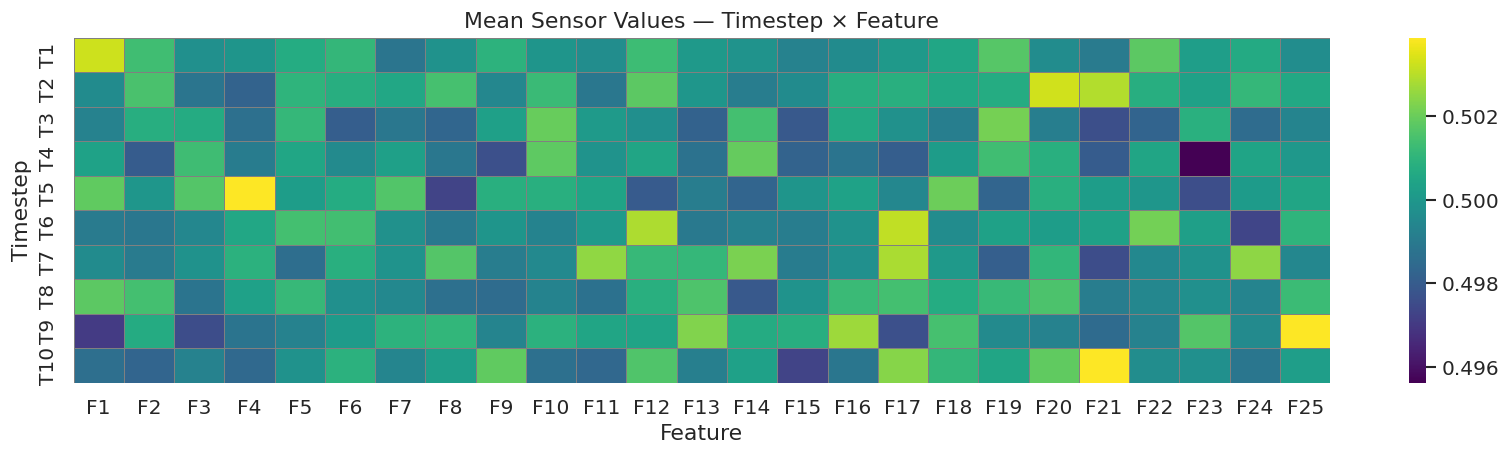

In [ ]:
# ── Heatmap: mean sensor value per (timestep × feature) ───────────────────────
mean_heatmap = X.mean(axis=0)   # (10, 25)

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(
    mean_heatmap,
    ax=ax,
    cmap='viridis',
    xticklabels=[f'F{i+1}' for i in range(NUM_FEATURES)],
    yticklabels=[f'T{t+1}' for t in range(NUM_TIMESTEPS)],
    linewidths=0.3,
    linecolor='gray'
)
ax.set_title('Mean Sensor Values — Timestep × Feature')
ax.set_xlabel('Feature')
ax.set_ylabel('Timestep')
plt.tight_layout()
plt.savefig('eda_heatmap.png', bbox_inches='tight')
plt.show()

## SECTION 4: Train / Test Split & DataLoaders

In [ ]:
TEST_SIZE  = 0.20   # 20 % held-out validation
BATCH_SIZE = 64

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=SEED,
    stratify=y          # preserve class proportions
)

print(f'Train : {X_train.shape[0]} samples')
print(f'Val   : {X_val.shape[0]}   samples')


class SensorDataset(Dataset):
    """Simple PyTorch Dataset wrapping numpy arrays."""

    def __init__(self, X: np.ndarray, y: np.ndarray):
        # Convert to tensors once; keeps DataLoader fast
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


train_ds = SensorDataset(X_train, y_train)
val_ds   = SensorDataset(X_val,   y_val)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=(DEVICE.type == 'cuda'))
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=(DEVICE.type == 'cuda'))

print(f'Train batches : {len(train_loader)}')
print(f'Val   batches : {len(val_loader)}')

Train : 32000 samples
Val   : 8000   samples
Train batches : 500
Val   batches : 125


## SECTION 5: Attention-Based Transformer Classifier

### Architecture summary
```
Input (batch, 10, 25)
  → Linear projection     (25 → 64)
  → Sinusoidal positional encoding
  → Multi-head self-attention (4 heads)  ← attention weights extracted here
  → Add & LayerNorm
  → Feed-forward block (64 → 256 → 64)
  → Add & LayerNorm
  → Global average pooling  (batch, 64)
  → MLP classifier (64 → 32 → 4)
```

In [ ]:
class PositionalEncoding(nn.Module):
    """
    Classic sinusoidal positional encoding (Vaswani et al. 2017).
    Adds a fixed, non-learned position signal so the model can
    distinguish timestep 1 from timestep 10.
    """

    def __init__(self, d_model: int, max_len: int = 10, dropout: float = 0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)

        # Build the (max_len, d_model) encoding matrix once
        pe  = torch.zeros(max_len, d_model)                        # (T, D)
        pos = torch.arange(max_len, dtype=torch.float).unsqueeze(1) # (T, 1)
        div = torch.exp(
            torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model)
        )                                                           # (D/2,)
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        # Register as buffer so it moves with .to(device) but isn't a parameter
        self.register_buffer('pe', pe.unsqueeze(0))                # (1, T, D)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (batch, T, D)
        return self.dropout(x + self.pe[:, :x.size(1), :])


class TransformerBlock(nn.Module):
    """
    One Transformer encoder block:
      - Multi-head self-attention  (returns weights)
      - Residual + LayerNorm
      - Feed-forward  (expand → GELU → contract)
      - Residual + LayerNorm
    """

    def __init__(self, d_model: int, n_heads: int, ff_dim: int, dropout: float):
        super().__init__()
        # PyTorch MHA: batch_first=True expects (batch, seq, feature)
        self.attn     = nn.MultiheadAttention(
            embed_dim=d_model, num_heads=n_heads,
            dropout=dropout, batch_first=True
        )
        self.norm1    = nn.LayerNorm(d_model)
        self.norm2    = nn.LayerNorm(d_model)
        self.ff       = nn.Sequential(
            nn.Linear(d_model, ff_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(ff_dim, d_model),
            nn.Dropout(dropout),
        )

    def forward(self, x: torch.Tensor):
        # ── Self-attention with residual connection ────────────────────────────
        # need_weights=True  → returns (output, attn_weights)
        # average_attn_weights=False → keep per-head weights (batch, heads, T, T)
        attn_out, attn_weights = self.attn(
            x, x, x,
            need_weights=True,
            average_attn_weights=False
        )
        x = self.norm1(x + attn_out)

        # ── Feed-forward with residual connection ──────────────────────────────
        x = self.norm2(x + self.ff(x))

        return x, attn_weights   # attn_weights: (batch, heads, T, T)


class SensorTransformer(nn.Module):
    """
    Full Transformer classifier for the sensor-cycle risk task.

    Parameters
    ----------
    in_features : input feature dim per timestep (25)
    d_model     : internal embedding dimension (64)
    n_heads     : number of attention heads (4)
    ff_dim      : feed-forward hidden size (256)
    dropout     : dropout rate
    n_classes   : output classes (4)
    """

    def __init__(
        self,
        in_features: int = 25,
        d_model: int = 64,
        n_heads: int = 4,
        ff_dim: int  = 256,
        dropout: float = 0.2,
        n_classes: int = 4,
    ):
        super().__init__()

        # 1. Linear projection: 25 → 64
        self.input_proj = nn.Linear(in_features, d_model)

        # 2. Positional encoding
        self.pos_enc = PositionalEncoding(d_model, max_len=NUM_TIMESTEPS, dropout=dropout)

        # 3. Single Transformer block  (can stack more for larger datasets)
        self.transformer_block = TransformerBlock(d_model, n_heads, ff_dim, dropout)

        # 4. Global average pooling  (batch, T, D) → (batch, D)
        # (done inline in forward)

        # 5. MLP classifier
        self.classifier = nn.Sequential(
            nn.Linear(d_model, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, n_classes),
        )

    def forward(self, x: torch.Tensor):
        """
        x : (batch, 10, 25)
        Returns
        -------
        logits       : (batch, 4)
        attn_weights : (batch, heads, 10, 10)
        """
        # Project features
        x = self.input_proj(x)             # (batch, 10, 64)

        # Add positional information
        x = self.pos_enc(x)                # (batch, 10, 64)

        # Transformer block
        x, attn_weights = self.transformer_block(x)   # x: (batch,10,64)

        # Global average pool over the time dimension
        x = x.mean(dim=1)                  # (batch, 64)

        # Classification head
        logits = self.classifier(x)        # (batch, 4)

        return logits, attn_weights


# ── Instantiate and inspect ───────────────────────────────────────────────────
model = SensorTransformer().to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
train_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters     : {total_params:,}')
print(f'Trainable parameters : {train_params:,}')
print(model)

Total parameters     : 53,860
Trainable parameters : 53,860
SensorTransformer(
  (input_proj): Linear(in_features=25, out_features=64, bias=True)
  (pos_enc): PositionalEncoding(
    (dropout): Dropout(p=0.2, inplace=False)
  )
  (transformer_block): TransformerBlock(
    (attn): MultiheadAttention(
      (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
    )
    (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
    (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
    (ff): Sequential(
      (0): Linear(in_features=64, out_features=256, bias=True)
      (1): GELU(approximate='none')
      (2): Dropout(p=0.2, inplace=False)
      (3): Linear(in_features=256, out_features=64, bias=True)
      (4): Dropout(p=0.2, inplace=False)
    )
  )
  (classifier): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=32, out_features=4, 

## SECTION 6: Training

We use:
- **CrossEntropyLoss** (multi-class)
- **AdamW** optimizer (weight decay acts as L2 regularisation)
- **CosineAnnealingLR** scheduler (smooth LR decay)
- **Early stopping** (patience = 15 epochs on validation loss)

In [ ]:
# ── Hyperparameters ────────────────────────────────────────────────────────────
MAX_EPOCHS    = 100
LR            = 3e-4
WEIGHT_DECAY  = 1e-4
ES_PATIENCE   = 15    # early-stopping patience (epochs)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=MAX_EPOCHS)


def run_epoch(loader, train: bool):
    """One full pass over `loader`. Returns (loss, accuracy, macro_f1)."""
    model.train() if train else model.eval()
    total_loss, all_preds, all_labels = 0.0, [], []

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for Xb, yb in loader:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)

            logits, _ = model(Xb)
            loss = criterion(logits, yb)

            if train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # gradient clipping
                optimizer.step()

            total_loss += loss.item() * Xb.size(0)
            preds = logits.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(yb.cpu().numpy())

    n       = len(all_labels)
    avg_loss = total_loss / n
    acc      = accuracy_score(all_labels, all_preds)
    f1       = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    return avg_loss, acc, f1


# ── Training loop ─────────────────────────────────────────────────────────────
history = {'train_loss': [], 'val_loss': [],
           'train_acc':  [], 'val_acc':  [],
           'train_f1':   [], 'val_f1':   []}

best_val_loss  = float('inf')
patience_counter = 0
best_state     = None

for epoch in range(1, MAX_EPOCHS + 1):
    tr_loss, tr_acc, tr_f1 = run_epoch(train_loader, train=True)
    vl_loss, vl_acc, vl_f1 = run_epoch(val_loader,   train=False)
    scheduler.step()

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(vl_acc)
    history['train_f1'].append(tr_f1)
    history['val_f1'].append(vl_f1)

    # ── Early stopping ─────────────────────────────────────────────────────
    if vl_loss < best_val_loss:
        best_val_loss    = vl_loss
        patience_counter = 0
        best_state       = {k: v.cpu().clone() for k, v in model.state_dict().items()}
    else:
        patience_counter += 1

    if epoch % 10 == 0 or patience_counter >= ES_PATIENCE:
        print(f'Epoch {epoch:03d} | '
              f'Train loss {tr_loss:.4f} acc {tr_acc:.3f} f1 {tr_f1:.3f} | '
              f'Val loss {vl_loss:.4f} acc {vl_acc:.3f} f1 {vl_f1:.3f}')

    if patience_counter >= ES_PATIENCE:
        print(f'\nEarly stopping at epoch {epoch} (patience={ES_PATIENCE}).')
        break

# ── Restore best weights ──────────────────────────────────────────────────────
model.load_state_dict({k: v.to(DEVICE) for k, v in best_state.items()})
print('\nBest model weights restored.')

Epoch 010 | Train loss 1.2817 acc 0.373 f1 0.355 | Val loss 1.2641 acc 0.388 f1 0.375
Epoch 020 | Train loss 1.2653 acc 0.387 f1 0.372 | Val loss 1.2597 acc 0.384 f1 0.373
Epoch 030 | Train loss 1.2586 acc 0.389 f1 0.374 | Val loss 1.2548 acc 0.387 f1 0.365
Epoch 040 | Train loss 1.2558 acc 0.391 f1 0.376 | Val loss 1.2553 acc 0.390 f1 0.373
Epoch 050 | Train loss 1.2506 acc 0.395 f1 0.377 | Val loss 1.2551 acc 0.386 f1 0.370
Epoch 060 | Train loss 1.2475 acc 0.395 f1 0.377 | Val loss 1.2520 acc 0.385 f1 0.368
Epoch 068 | Train loss 1.2464 acc 0.398 f1 0.381 | Val loss 1.2539 acc 0.389 f1 0.372

Early stopping at epoch 68 (patience=15).

Best model weights restored.


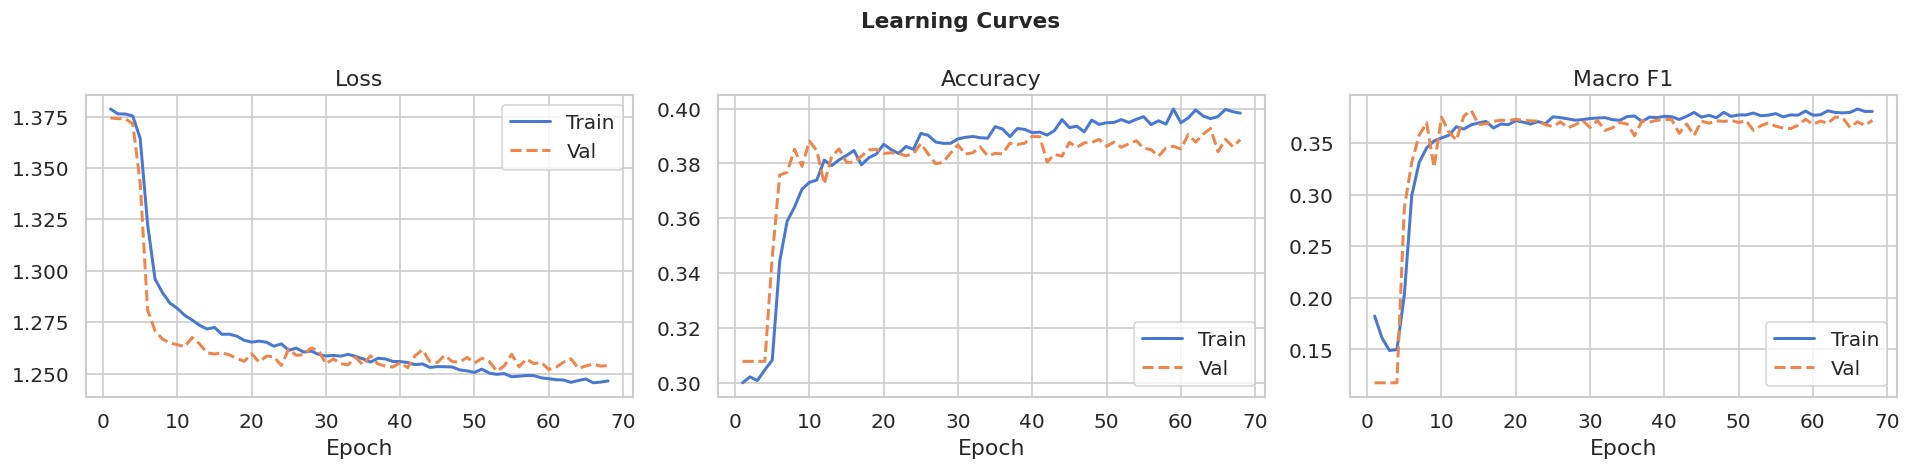

In [ ]:
# ── Learning curves ────────────────────────────────────────────────────────────
epochs_ran = len(history['train_loss'])
ep = range(1, epochs_ran + 1)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, metric, title in zip(
    axes,
    [('train_loss', 'val_loss'), ('train_acc', 'val_acc'), ('train_f1', 'val_f1')],
    ['Loss', 'Accuracy', 'Macro F1']
):
    tr_key, vl_key = metric
    ax.plot(ep, history[tr_key], label='Train', linewidth=1.8)
    ax.plot(ep, history[vl_key], label='Val',   linewidth=1.8, linestyle='--')
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.legend()

plt.suptitle('Learning Curves', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('learning_curves.png', bbox_inches='tight')
plt.show()

## SECTION 7: Model Evaluation

══ Validation Metrics ══════════════════════
  Accuracy  : 0.3871
  Precision : 0.3812  (macro)
  Recall    : 0.3688  (macro)
  F1        : 0.3667  (macro)

              precision    recall  f1-score   support

     No Risk       0.36      0.47      0.41      2120
    Low Risk       0.32      0.24      0.27      1623
 Medium Risk       0.42      0.26      0.32      1795
Catastrophic       0.43      0.51      0.46      2462

    accuracy                           0.39      8000
   macro avg       0.38      0.37      0.37      8000
weighted avg       0.39      0.39      0.38      8000



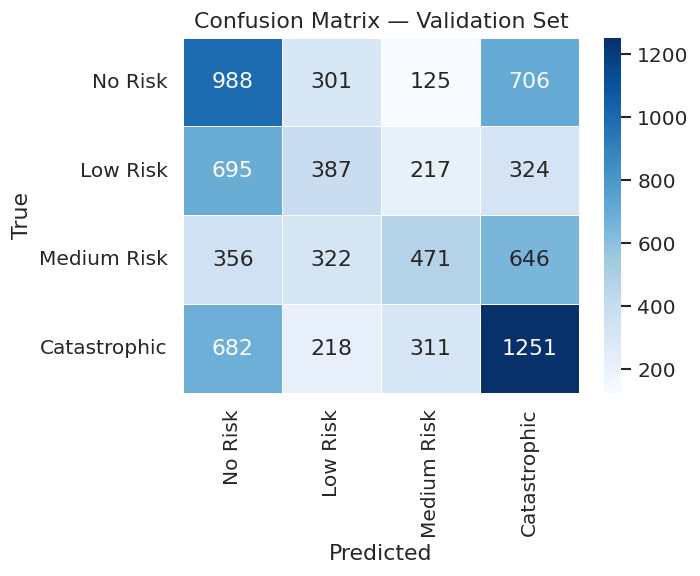

In [ ]:
def evaluate_model(loader):
    """Collect all predictions and labels from `loader`."""
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for Xb, yb in loader:
            Xb = Xb.to(DEVICE)
            logits, _ = model(Xb)
            all_preds.extend(logits.argmax(1).cpu().numpy())
            all_labels.extend(yb.numpy())
    return np.array(all_labels), np.array(all_preds)


true_labels, pred_labels = evaluate_model(val_loader)

acc  = accuracy_score(true_labels, pred_labels)
prec = precision_score(true_labels, pred_labels, average='macro', zero_division=0)
rec  = recall_score(true_labels,   pred_labels, average='macro', zero_division=0)
f1   = f1_score(true_labels,      pred_labels, average='macro', zero_division=0)

print('══ Validation Metrics ══════════════════════')
print(f'  Accuracy  : {acc:.4f}')
print(f'  Precision : {prec:.4f}  (macro)')
print(f'  Recall    : {rec:.4f}  (macro)')
print(f'  F1        : {f1:.4f}  (macro)')
print()
print(classification_report(true_labels, pred_labels,
                             target_names=CLASS_NAMES, zero_division=0))

# ── Confusion matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(true_labels, pred_labels)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
    linewidths=0.5, ax=ax
)
ax.set_title('Confusion Matrix — Validation Set')
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
plt.tight_layout()
plt.savefig('confusion_matrix.png', bbox_inches='tight')
plt.show()

## SECTION 8: Attention Analysis

The attention weight tensor has shape **(batch, heads, 10, 10)**.
Each entry `A[b, h, i, j]` is the weight query-timestep `i` assigns to key-timestep `j`.

We define **timestep importance** as the mean attention *received* by each timestep (i.e. column mean of the attention matrix), averaged over all samples and heads.

In [ ]:
def collect_attention_weights(loader):
    """
    Run the model on `loader` and collect all attention weight tensors.

    Returns
    -------
    attn_all : np.ndarray, shape (N_val, heads, 10, 10)
    """
    model.eval()
    all_attn = []
    with torch.no_grad():
        for Xb, _ in loader:
            Xb = Xb.to(DEVICE)
            _, attn_weights = model(Xb)   # (batch, heads, T, T)
            all_attn.append(attn_weights.cpu().numpy())

    return np.concatenate(all_attn, axis=0)   # (N_val, heads, T, T)


attn_all = collect_attention_weights(val_loader)
print(f'Attention weight tensor shape: {attn_all.shape}')
print('  Axes: (samples, heads, query_timestep, key_timestep)')

Attention weight tensor shape: (8000, 4, 10, 10)
  Axes: (samples, heads, query_timestep, key_timestep)


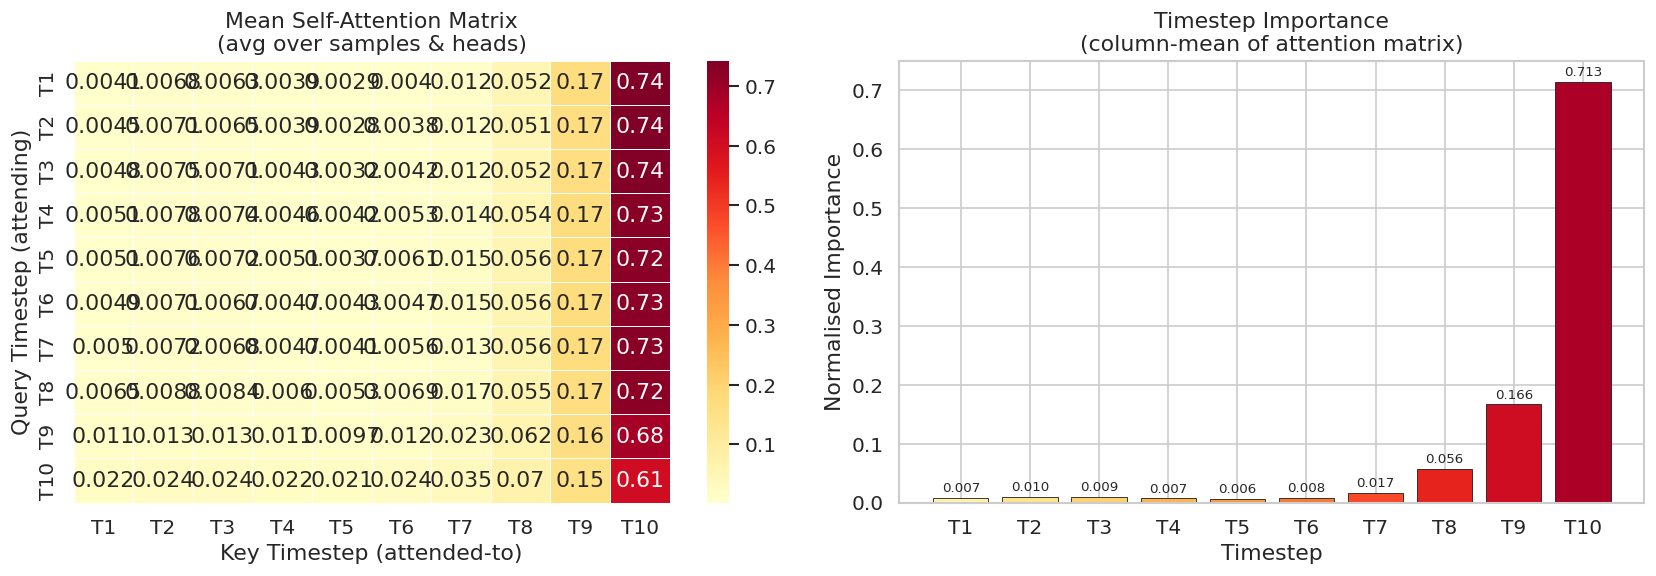


══ Attention-Based Timestep Ranking ═══════════
  Rank  1: Timestep 10  (score = 0.7135)
  Rank  2: Timestep 9  (score = 0.1663)
  Rank  3: Timestep 8  (score = 0.0564)
  Rank  4: Timestep 7  (score = 0.0168)
  Rank  5: Timestep 2  (score = 0.0097)
  Rank  6: Timestep 3  (score = 0.0093)
  Rank  7: Timestep 6  (score = 0.0076)
  Rank  8: Timestep 1  (score = 0.0073)
  Rank  9: Timestep 4  (score = 0.0070)
  Rank 10: Timestep 5  (score = 0.0061)


In [ ]:
# ── Mean attention matrix (averaged over samples and heads) ───────────────────
mean_attn_matrix = attn_all.mean(axis=(0, 1))   # (10, 10)

# ── Timestep importance = mean attention *received* = column mean ──────────────
#    For each timestep j, how much attention do all query positions assign to it?
col_importance = mean_attn_matrix.mean(axis=0)   # (10,)
# Normalise to [0, 1] so it is comparable with ablation drops
attn_importance = col_importance / col_importance.sum()

ts_labels = [f'T{t+1}' for t in range(NUM_TIMESTEPS)]

# ── Plot 1: attention heatmap ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
sns.heatmap(
    mean_attn_matrix,
    ax=ax, cmap='YlOrRd',
    xticklabels=ts_labels, yticklabels=ts_labels,
    linewidths=0.3, annot=(NUM_TIMESTEPS <= 10)
)
ax.set_title('Mean Self-Attention Matrix\n(avg over samples & heads)')
ax.set_xlabel('Key Timestep (attended-to)')
ax.set_ylabel('Query Timestep (attending)')

# ── Plot 2: importance bar chart ──────────────────────────────────────────────
ax = axes[1]
colors = sns.color_palette('YlOrRd', NUM_TIMESTEPS)
bars   = ax.bar(ts_labels, attn_importance, color=colors, edgecolor='k', linewidth=0.5)
ax.bar_label(bars, fmt='%.3f', padding=2, fontsize=8)
ax.set_title('Timestep Importance\n(column-mean of attention matrix)')
ax.set_xlabel('Timestep')
ax.set_ylabel('Normalised Importance')

plt.tight_layout()
plt.savefig('attention_analysis.png', bbox_inches='tight')
plt.show()

# ── Ranked list ───────────────────────────────────────────────────────────────
attn_ranking = np.argsort(attn_importance)[::-1]
print('\n══ Attention-Based Timestep Ranking ═══════════')
for rank, idx in enumerate(attn_ranking, 1):
    print(f'  Rank {rank:2d}: Timestep {idx+1}  (score = {attn_importance[idx]:.4f})')

## SECTION 9: Leave-One-Timestep-Out Ablation

For each timestep `t` (1 … 10) we:
1. Copy the validation tensor
2. Zero out column `t` (replace with zeros — the model still sees something, but the features carry no signal)
3. Run inference
4. Compute **accuracy drop** and **F1 drop** relative to the baseline

A **large drop** ↔ the model heavily relied on that timestep.

In [ ]:
# ── Baseline metrics (no ablation) ───────────────────────────────────────────
baseline_acc = accuracy_score(true_labels, pred_labels)
baseline_f1  = f1_score(true_labels, pred_labels, average='macro', zero_division=0)
print(f'Baseline — Acc: {baseline_acc:.4f}  |  Macro-F1: {baseline_f1:.4f}\n')

# ── Ablation loop ─────────────────────────────────────────────────────────────
ablation_results = []

# Convert full val arrays to tensors once
X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.long)

model.eval()

for t in range(NUM_TIMESTEPS):
    # Deep-copy the validation data and zero the t-th timestep
    X_ablated = X_val_t.clone()
    X_ablated[:, t, :] = 0.0

    # Build a temporary DataLoader for this ablated version
    abl_ds     = torch.utils.data.TensorDataset(X_ablated, y_val_t)
    abl_loader = DataLoader(abl_ds, batch_size=BATCH_SIZE, shuffle=False)

    abl_preds = []
    with torch.no_grad():
        for Xb, _ in abl_loader:
            Xb = Xb.to(DEVICE)
            logits, _ = model(Xb)
            abl_preds.extend(logits.argmax(1).cpu().numpy())

    abl_acc = accuracy_score(y_val, abl_preds)
    abl_f1  = f1_score(y_val, abl_preds, average='macro', zero_division=0)

    acc_drop = baseline_acc - abl_acc
    f1_drop  = baseline_f1  - abl_f1

    ablation_results.append({
        'Timestep'    : t + 1,
        'Ablated_Acc' : abl_acc,
        'Ablated_F1'  : abl_f1,
        'Acc_Drop'    : acc_drop,
        'F1_Drop'     : f1_drop,
    })
    print(f'  T{t+1:02d} zeroed → Acc {abl_acc:.4f} (drop {acc_drop:+.4f})  '
          f'F1 {abl_f1:.4f} (drop {f1_drop:+.4f})')

ablation_df = pd.DataFrame(ablation_results)
ablation_df = ablation_df.set_index('Timestep')
print('\nAblation results table:')
print(ablation_df.to_string())

Baseline — Acc: 0.3871  |  Macro-F1: 0.3667

  T01 zeroed → Acc 0.3889 (drop -0.0018)  F1 0.3648 (drop +0.0019)
  T02 zeroed → Acc 0.3909 (drop -0.0037)  F1 0.3677 (drop -0.0010)
  T03 zeroed → Acc 0.3872 (drop -0.0001)  F1 0.3636 (drop +0.0030)
  T04 zeroed → Acc 0.3885 (drop -0.0014)  F1 0.3650 (drop +0.0017)
  T05 zeroed → Acc 0.3895 (drop -0.0024)  F1 0.3650 (drop +0.0016)
  T06 zeroed → Acc 0.3899 (drop -0.0028)  F1 0.3634 (drop +0.0033)
  T07 zeroed → Acc 0.3909 (drop -0.0037)  F1 0.3629 (drop +0.0038)
  T08 zeroed → Acc 0.3885 (drop -0.0014)  F1 0.3551 (drop +0.0115)
  T09 zeroed → Acc 0.3807 (drop +0.0064)  F1 0.3370 (drop +0.0297)
  T10 zeroed → Acc 0.2671 (drop +0.1200)  F1 0.1230 (drop +0.2437)

Ablation results table:
          Ablated_Acc  Ablated_F1  Acc_Drop   F1_Drop
Timestep                                             
1            0.388875    0.364779 -0.001750  0.001885
2            0.390875    0.367688 -0.003750 -0.001024
3            0.387250    0.363636 -0.000125 

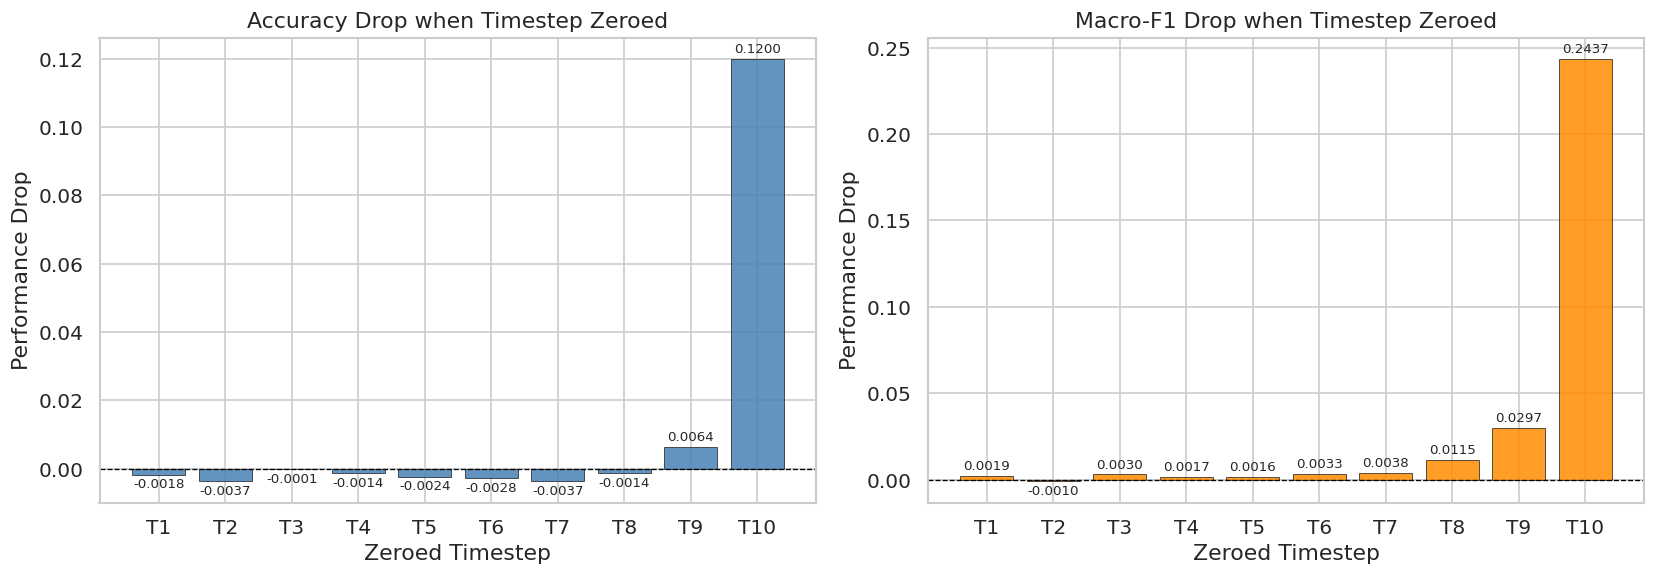


══ Ablation-Based Timestep Ranking (by F1 Drop) ════════
 Rank |  Timestep |   Acc Drop |    F1 Drop
---------------------------------------------
    1 |        10 |     0.1200 |     0.2437
    2 |         9 |     0.0064 |     0.0297
    3 |         8 |    -0.0014 |     0.0115
    4 |         7 |    -0.0037 |     0.0038
    5 |         6 |    -0.0028 |     0.0033
    6 |         3 |    -0.0001 |     0.0030
    7 |         1 |    -0.0018 |     0.0019
    8 |         4 |    -0.0014 |     0.0017
    9 |         5 |    -0.0024 |     0.0016
   10 |         2 |    -0.0037 |    -0.0010


In [ ]:
# ── Ablation plots ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, title, color in zip(
    axes,
    ['Acc_Drop', 'F1_Drop'],
    ['Accuracy Drop when Timestep Zeroed', 'Macro-F1 Drop when Timestep Zeroed'],
    ['steelblue', 'darkorange']
):
    vals = ablation_df[col].values
    bars = ax.bar(ts_labels, vals, color=color, alpha=0.85, edgecolor='k', linewidth=0.5)
    ax.bar_label(bars, fmt='%.4f', padding=2, fontsize=8)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title(title)
    ax.set_xlabel('Zeroed Timestep')
    ax.set_ylabel('Performance Drop')

plt.tight_layout()
plt.savefig('ablation_results.png', bbox_inches='tight')
plt.show()

# ── Ranked by F1 drop ─────────────────────────────────────────────────────────
abl_ranking = ablation_df['F1_Drop'].sort_values(ascending=False)
print('\n══ Ablation-Based Timestep Ranking (by F1 Drop) ════════')
print(f'{"Rank":>5} | {"Timestep":>9} | {"Acc Drop":>10} | {"F1 Drop":>10}')
print('-' * 45)
for rank, (ts, f1_d) in enumerate(abl_ranking.items(), 1):
    acc_d = ablation_df.loc[ts, 'Acc_Drop']
    print(f'{rank:>5} | {ts:>9} | {acc_d:>10.4f} | {f1_d:>10.4f}')

## SECTION 10: Compare Attention vs Ablation

We correlate the two importance signals:
- **Attention importance** (normalised column-mean of attention matrix)
- **Ablation importance** (F1 drop when timestep is zeroed)

A high correlation suggests the model's attention is a reliable proxy for actual predictive utility.

In [ ]:
# ── Build comparison table ────────────────────────────────────────────────────
compare_df = pd.DataFrame({
    'Timestep'            : list(range(1, 11)),
    'Attention_Importance': attn_importance,
    'Acc_Drop'            : ablation_df['Acc_Drop'].values,
    'F1_Drop'             : ablation_df['F1_Drop'].values,
})
compare_df = compare_df.set_index('Timestep')
print('Comparison Table:')
print(compare_df.to_string(float_format='{:.4f}'.format))

# ── Correlation metrics ───────────────────────────────────────────────────────
attn_vec = compare_df['Attention_Importance'].values
f1d_vec  = compare_df['F1_Drop'].values
accd_vec = compare_df['Acc_Drop'].values

sp_r_f1,  sp_p_f1  = spearmanr(attn_vec, f1d_vec)
pe_r_f1,  pe_p_f1  = pearsonr(attn_vec,  f1d_vec)
sp_r_acc, sp_p_acc = spearmanr(attn_vec, accd_vec)
pe_r_acc, pe_p_acc = pearsonr(attn_vec,  accd_vec)

print('\n══ Correlation: Attention vs Ablation ══════════════════════')
print(f'  Spearman  (vs F1 Drop ) : r = {sp_r_f1:.3f}  (p = {sp_p_f1:.3f})')
print(f'  Pearson   (vs F1 Drop ) : r = {pe_r_f1:.3f}  (p = {pe_p_f1:.3f})')
print(f'  Spearman  (vs Acc Drop) : r = {sp_r_acc:.3f}  (p = {sp_p_acc:.3f})')
print(f'  Pearson   (vs Acc Drop) : r = {pe_r_acc:.3f}  (p = {pe_p_acc:.3f})')

Comparison Table:
          Attention_Importance  Acc_Drop  F1_Drop
Timestep                                         
1                       0.0073   -0.0018   0.0019
2                       0.0097   -0.0037  -0.0010
3                       0.0093   -0.0001   0.0030
4                       0.0070   -0.0014   0.0017
5                       0.0061   -0.0024   0.0016
6                       0.0076   -0.0028   0.0033
7                       0.0168   -0.0037   0.0038
8                       0.0564   -0.0014   0.0115
9                       0.1663    0.0064   0.0297
10                      0.7135    0.1200   0.2437

══ Correlation: Attention vs Ablation ══════════════════════
  Spearman  (vs F1 Drop ) : r = 0.806  (p = 0.005)
  Pearson   (vs F1 Drop ) : r = 0.994  (p = 0.000)
  Spearman  (vs Acc Drop) : r = 0.415  (p = 0.233)
  Pearson   (vs Acc Drop) : r = 0.987  (p = 0.000)


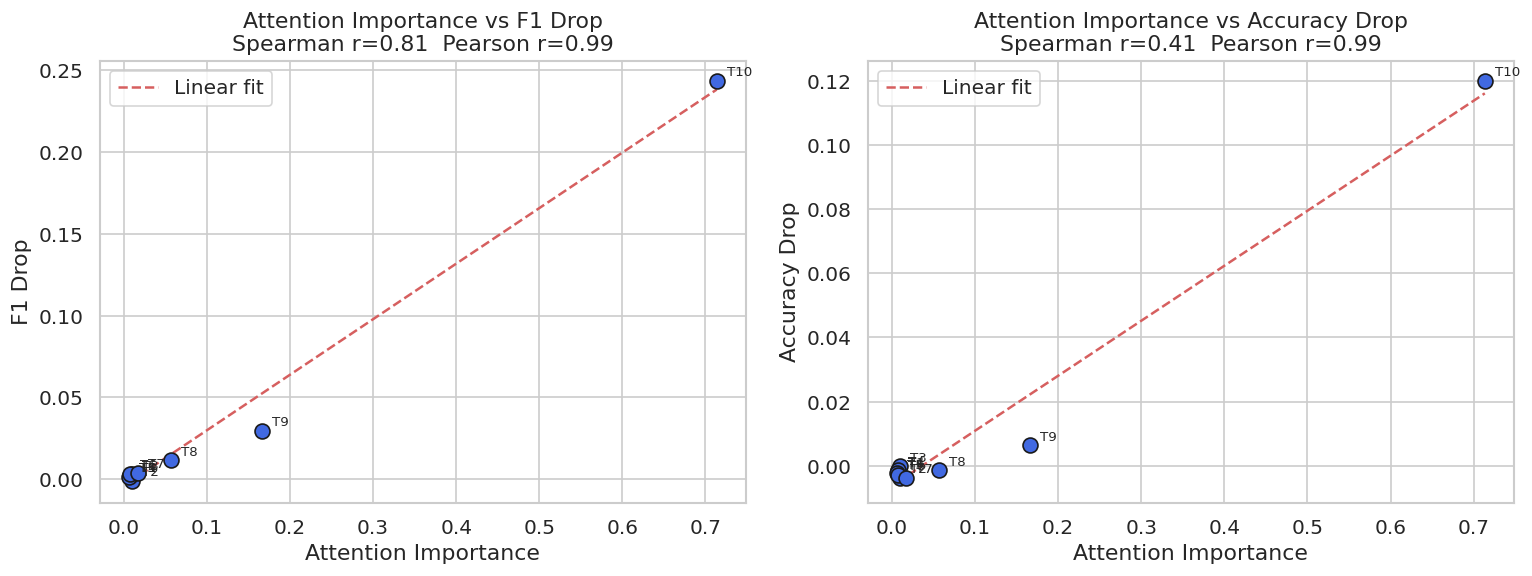


Interpretation:
  Spearman correlation (Attention vs F1 Drop): 0.806 — strong alignment.
  → Attention weights are a RELIABLE proxy for ablation-based importance.


In [ ]:
# ── Scatter: Attention importance vs F1 Drop ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, y_col, y_label, corr in zip(
    axes,
    ['F1_Drop', 'Acc_Drop'],
    ['F1 Drop', 'Accuracy Drop'],
    [(sp_r_f1, pe_r_f1), (sp_r_acc, pe_r_acc)]
):
    y = compare_df[y_col].values
    ax.scatter(attn_vec, y, s=80, zorder=3, color='royalblue', edgecolors='k')
    for ts_idx, (av, yv) in enumerate(zip(attn_vec, y)):
        ax.annotate(f'T{ts_idx+1}', (av, yv),
                    textcoords='offset points', xytext=(6, 3), fontsize=8)
    # Trend line
    m, b = np.polyfit(attn_vec, y, 1)
    xfit = np.linspace(attn_vec.min(), attn_vec.max(), 50)
    ax.plot(xfit, m * xfit + b, 'r--', linewidth=1.5, label='Linear fit')
    sp_r, pe_r = corr
    ax.set_title(f'Attention Importance vs {y_label}\n'
                 f'Spearman r={sp_r:.2f}  Pearson r={pe_r:.2f}')
    ax.set_xlabel('Attention Importance')
    ax.set_ylabel(y_label)
    ax.legend()

plt.tight_layout()
plt.savefig('attention_vs_ablation.png', bbox_inches='tight')
plt.show()

# ── Interpretation ────────────────────────────────────────────────────────────
def interpret_corr(r):
    if abs(r) >= 0.7:  return 'strong'
    if abs(r) >= 0.4:  return 'moderate'
    return 'weak'

print(f'\nInterpretation:')
print(f'  Spearman correlation (Attention vs F1 Drop): {sp_r_f1:.3f} — {interpret_corr(sp_r_f1)} alignment.')
if abs(sp_r_f1) >= 0.5:
    print('  → Attention weights are a RELIABLE proxy for ablation-based importance.')
else:
    print('  → Attention weights show LIMITED alignment with ablation importance.')
    print('    This is common: attention weights reflect the model\'s internal routing,'
          ' not necessarily causal feature importance.')

## SECTION 11: Final Conclusions

Automatically synthesise findings.

In [ ]:
# ── Most important timestep per method ───────────────────────────────────────
best_attn_ts  = int(np.argmax(attn_importance)) + 1
best_abl_ts   = int(ablation_df['F1_Drop'].idxmax())

# ── Top-3 combined (rank by normalised sum of attention + normalised F1 drop) ─
norm_attn = attn_importance / (attn_importance.max() + 1e-9)
norm_abl  = compare_df['F1_Drop'].values
norm_abl  = (norm_abl - norm_abl.min()) / (norm_abl.max() - norm_abl.min() + 1e-9)
combined  = (norm_attn + norm_abl) / 2.0
top3_idx  = np.argsort(combined)[::-1][:3]

# ── Early vs late ─────────────────────────────────────────────────────────────
early_score = combined[:5].mean()
late_score  = combined[5:].mean()
temporal    = 'LATER' if late_score > early_score else 'EARLIER'

print('═' * 55)
print('  FINAL CONCLUSIONS')
print('═' * 55)
print(f'  Most important timestep (attention)  : T{best_attn_ts}')
print(f'  Most important timestep (ablation)   : T{best_abl_ts}')
print()
print('  Top 3 timesteps overall (combined score):')
for rank, idx in enumerate(top3_idx, 1):
    ts = idx + 1
    print(f'    Rank {rank}: Timestep T{ts}  '
          f'(attn={attn_importance[idx]:.3f},  '
          f'F1 drop={compare_df["F1_Drop"].values[idx]:.4f},  '
          f'combined={combined[idx]:.3f})')
print()
print(f'  Early timesteps (T1–T5)  avg combined score : {early_score:.3f}')
print(f'  Late  timesteps (T6–T10) avg combined score : {late_score:.3f}')
print(f'  → {temporal} timesteps appear more informative for risk prediction.')
print('═' * 55)

═══════════════════════════════════════════════════════
  FINAL CONCLUSIONS
═══════════════════════════════════════════════════════
  Most important timestep (attention)  : T10
  Most important timestep (ablation)   : T10

  Top 3 timesteps overall (combined score):
    Rank 1: Timestep T10  (attn=0.713,  F1 drop=0.2437,  combined=1.000)
    Rank 2: Timestep T9  (attn=0.166,  F1 drop=0.0297,  combined=0.179)
    Rank 3: Timestep T8  (attn=0.056,  F1 drop=0.0115,  combined=0.065)

  Early timesteps (T1–T5)  avg combined score : 0.011
  Late  timesteps (T6–T10) avg combined score : 0.256
  → LATER timesteps appear more informative for risk prediction.
═══════════════════════════════════════════════════════


## SECTION 12: Save Results

In [ ]:
import os
os.makedirs('results', exist_ok=True)

# ── 1. Trained model weights ──────────────────────────────────────────────────
torch.save(model.state_dict(), 'results/sensor_transformer.pth')
print('Saved: results/sensor_transformer.pth')

# ── 2. Attention importance CSV ───────────────────────────────────────────────
attn_csv = pd.DataFrame({
    'Timestep'            : list(range(1, 11)),
    'Attention_Importance': attn_importance,
    'Attention_Rank'      : pd.Series(attn_importance).rank(ascending=False).astype(int).values
})
attn_csv.to_csv('results/attention_importance.csv', index=False)
print('Saved: results/attention_importance.csv')

# ── 3. Ablation results CSV ───────────────────────────────────────────────────
ablation_df.to_csv('results/ablation_results.csv')
print('Saved: results/ablation_results.csv')

# ── 4. Comparison table CSV ───────────────────────────────────────────────────
compare_df.to_csv('results/comparison_table.csv')
print('Saved: results/comparison_table.csv')

# ── 5. Figures (already saved inline; copy to results/) ──────────────────────
import shutil
for fig_name in ['eda_overview.png', 'eda_heatmap.png', 'learning_curves.png',
                 'confusion_matrix.png', 'attention_analysis.png',
                 'ablation_results.png', 'attention_vs_ablation.png']:
    if os.path.exists(fig_name):
        shutil.copy(fig_name, f'results/{fig_name}')
        print(f'Saved: results/{fig_name}')

print('\n✓ All results saved to ./results/')

Saved: results/sensor_transformer.pth
Saved: results/attention_importance.csv
Saved: results/ablation_results.csv
Saved: results/comparison_table.csv
Saved: results/eda_overview.png
Saved: results/eda_heatmap.png
Saved: results/learning_curves.png
Saved: results/confusion_matrix.png
Saved: results/attention_analysis.png
Saved: results/ablation_results.png
Saved: results/attention_vs_ablation.png

✓ All results saved to ./results/


## SECTION 13: Generate Competition Submission

This section:
1. Loads `test.txt` using the **same parser** as train (comma-separated, 10 sensor rows per sample, but **no label lines**)
2. Runs the trained model on the test set
3. Saves `submission.csv` with exactly two columns: `sample_id` and `risk_level`

**Set `TEST_PATH`** to your test file path before running.

In [ ]:
# ── USER: set path to your test file ────────────────────────────────────────
TEST_PATH = 'test.txt'   # e.g. '/content/test.txt'


def load_test_dataset(path: str):
    """
    Load the test file.

    The test file has the same sensor-row format as train.txt:
        sample_id, timepoint, f1, f2, ..., f25
    but contains NO label lines — every line is a sensor row.
    Rows are grouped into blocks of NUM_TIMESTEPS (10) in order.

    If the competition test file DOES include dummy label lines
    (e.g. all zeros), set HAS_DUMMY_LABELS = True below.

    Returns
    -------
    X_test      : np.ndarray  shape (N, 10, 25)
    sample_ids  : list of int  — the sample_id from the first row of each block
    """
    HAS_DUMMY_LABELS = False   # <-- set True if test.txt has label lines like train.txt

    with open(path, 'r') as fh:
        lines = [ln.strip() for ln in fh if ln.strip()]

    # ── Detect whether label lines are present ──────────────────────────────
    # A label line has exactly 1 token (the integer); a sensor row has 27.
    # Auto-detect by checking if line at index NUM_TIMESTEPS looks like a label.
    if len(lines) > NUM_TIMESTEPS:
        probe = lines[NUM_TIMESTEPS].split(',')
        if len(probe) == 1:
            HAS_DUMMY_LABELS = True
            print('Auto-detected: test file contains label/dummy lines — will skip them.')
        else:
            print('Auto-detected: test file has NO label lines — pure sensor rows only.')

    BLOCK = NUM_TIMESTEPS + (1 if HAS_DUMMY_LABELS else 0)
    num_blocks = len(lines) // BLOCK
    print(f'Total non-empty lines : {len(lines)}')
    print(f'Block size            : {BLOCK}')
    print(f'Blocks (test samples) : {num_blocks}')

    X_list, sample_ids = [], []
    skipped = 0

    for b in range(num_blocks):
        start = b * BLOCK
        block = lines[start : start + BLOCK]
        sensor_rows = block[:NUM_TIMESTEPS]   # always first 10 lines

        ok = True
        timesteps = []
        sid = None

        for t, row in enumerate(sensor_rows):
            tokens = row.split(',')
            if len(tokens) < 2 + NUM_FEATURES:
                print(f'[WARN] Block {b}, timestep {t}: only {len(tokens)} tokens — skipping.')
                ok = False
                break
            try:
                if t == 0:
                    sid = int(tokens[0])   # capture sample_id from first row
                features = [float(v) for v in tokens[2 : 2 + NUM_FEATURES]]
            except ValueError as e:
                print(f'[WARN] Block {b}, timestep {t}: parse error ({e}) — skipping.')
                ok = False
                break
            timesteps.append(features)

        if not ok:
            skipped += 1
            continue

        X_list.append(timesteps)
        sample_ids.append(sid)

    X_test = np.array(X_list, dtype=np.float32)   # (N, 10, 25)
    print(f'\nLoaded {len(X_list)} test samples  |  {skipped} skipped')
    print(f'X_test shape: {X_test.shape}')
    return X_test, sample_ids


X_test, test_sample_ids = load_test_dataset(TEST_PATH)


Auto-detected: test file has NO label lines — pure sensor rows only.
Total non-empty lines : 100000
Block size            : 10
Blocks (test samples) : 10000

Loaded 10000 test samples  |  0 skipped
X_test shape: (10000, 10, 25)


In [ ]:
# ── Run inference on test set ────────────────────────────────────────────────
model.eval()

test_ds     = SensorDataset(X_test, np.zeros(len(X_test), dtype=np.int64))  # dummy labels
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

all_preds = []
with torch.no_grad():
    for Xb, _ in test_loader:
        Xb = Xb.to(DEVICE)
        logits, _ = model(Xb)
        preds = logits.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)

print(f'Predictions generated: {len(all_preds)}')

# ── Prediction distribution sanity check ─────────────────────────────────────
pred_counts = Counter(all_preds)
print('\nPrediction distribution:')
for cls in range(NUM_CLASSES):
    n = pred_counts.get(cls, 0)
    print(f'  {cls}  {CLASS_NAMES[cls]:15s}: {n:6d}  ({100*n/max(len(all_preds),1):.1f}%)')

# ── Build submission DataFrame ────────────────────────────────────────────────
submission_df = pd.DataFrame({
    'sample_id'  : test_sample_ids,
    'risk_level' : all_preds
})

# Ensure sample_id is sorted in ascending order (matches sample_submission.csv)
submission_df = submission_df.sort_values('sample_id').reset_index(drop=True)

print('\nFirst 10 rows of submission:')
print(submission_df.head(10).to_string(index=False))

# ── Save ─────────────────────────────────────────────────────────────────────
submission_df.to_csv('submission.csv', index=False)
print('\n✓ submission.csv saved!')
print(f'  Rows    : {len(submission_df)}')
print(f'  Columns : {list(submission_df.columns)}')

# Also copy to results/ folder
import shutil
os.makedirs('results', exist_ok=True)
shutil.copy('submission.csv', 'results/submission.csv')
print('  Also saved to: results/submission.csv')


Predictions generated: 10000

Prediction distribution:
  0  No Risk        :   3559  (35.6%)
  1  Low Risk       :   1654  (16.5%)
  2  Medium Risk    :   1423  (14.2%)
  3  Catastrophic   :   3364  (33.6%)

First 10 rows of submission:
 sample_id  risk_level
     40000           0
     40001           3
     40002           3
     40003           1
     40004           3
     40005           0
     40006           2
     40007           3
     40008           3
     40009           0

✓ submission.csv saved!
  Rows    : 10000
  Columns : ['sample_id', 'risk_level']
  Also saved to: results/submission.csv


The final ANN model is in the next cell:

In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 1 OF 2  —  ANN on Timestep 10 only                                  ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

# ── Extract ONLY the 10th timestep (index 9) ─────────────────────────────────
# X_train / X_val / X_test shape: (N, 10, 25)
# We take index 9 → shape becomes (N, 25) — flat feature vector, no sequence
TIMESTEP_IDX = 9

X_train_t10 = X_train[:, TIMESTEP_IDX, :]   # (N_train, 25)
X_val_t10   = X_val[:,   TIMESTEP_IDX, :]   # (N_val,   25)
X_test_t10  = X_test[:,  TIMESTEP_IDX, :]   # (N_test,  25)

print(f'X_train_t10 shape : {X_train_t10.shape}')
print(f'X_val_t10   shape : {X_val_t10.shape}')
print(f'X_test_t10  shape : {X_test_t10.shape}')


# ── ANN model definition ──────────────────────────────────────────────────────
class ANNClassifier(nn.Module):
    """
    Deep ANN classifier trained on the 25 features of timestep 10 only.

    Architecture  (input: 25 features → output: 4 risk classes):
      Linear 25  → 256  + BatchNorm + GELU + Dropout
      Linear 256 → 512  + BatchNorm + GELU + Dropout
      Linear 512 → 512  + BatchNorm + GELU + Dropout
      Linear 512 → 256  + BatchNorm + GELU + Dropout
      Linear 256 → 128  + BatchNorm + GELU + Dropout
      Linear 128 → 4    (logits)

    Design choices:
      - Expand then contract (bottleneck shape) helps learn rich representations
        from only 25 input features
      - BatchNorm before activation stabilises training
      - GELU activation (smoother than ReLU, works better in deeper networks)
      - Residual (skip) connection between same-sized hidden layers
        to prevent vanishing gradients in the deeper layers
    """
    def __init__(self, input_size: int = 25, num_classes: int = 4,
                 dropout: float = 0.35):
        super().__init__()

        # ── Block 1: 25 → 256 ─────────────────────────────────────────────────
        self.block1 = nn.Sequential(
            nn.Linear(input_size, 256),
            nn.BatchNorm1d(256),
            nn.GELU(),
            nn.Dropout(dropout),
        )

        # ── Block 2: 256 → 512 ────────────────────────────────────────────────
        self.block2 = nn.Sequential(
            nn.Linear(256, 512),
            nn.BatchNorm1d(512),
            nn.GELU(),
            nn.Dropout(dropout),
        )

        # ── Block 3: 512 → 512  (residual) ────────────────────────────────────
        self.block3 = nn.Sequential(
            nn.Linear(512, 512),
            nn.BatchNorm1d(512),
            nn.GELU(),
            nn.Dropout(dropout),
        )
        # Skip connection: block2_out + block3_out (same size, no projection needed)

        # ── Block 4: 512 → 256 ────────────────────────────────────────────────
        self.block4 = nn.Sequential(
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.GELU(),
            nn.Dropout(dropout),
        )

        # ── Block 5: 256 → 128 ────────────────────────────────────────────────
        self.block5 = nn.Sequential(
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.GELU(),
            nn.Dropout(dropout),
        )

        # ── Output head ───────────────────────────────────────────────────────
        self.output = nn.Linear(128, num_classes)

        # ── Weight initialisation (He init for GELU layers) ───────────────────
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        # x: (batch, 25)
        x  = self.block1(x)          # (batch, 256)
        x  = self.block2(x)          # (batch, 512)
        res = x                       # save for residual
        x  = self.block3(x)          # (batch, 512)
        x  = x + res                  # residual add — same shape, no projection
        x  = self.block4(x)          # (batch, 256)
        x  = self.block5(x)          # (batch, 128)
        return self.output(x)         # (batch, 4)


# ── Dataset: no sequence dimension needed — SensorDataset works as-is ─────────
ann_train_ds = SensorDataset(X_train_t10, y_train)
ann_val_ds   = SensorDataset(X_val_t10,   y_val)

ann_train_loader = DataLoader(ann_train_ds, batch_size=BATCH_SIZE,
                               shuffle=True,  num_workers=0)
ann_val_loader   = DataLoader(ann_val_ds,   batch_size=BATCH_SIZE,
                               shuffle=False, num_workers=0)

# ── Instantiate model ─────────────────────────────────────────────────────────
ann_model = ANNClassifier().to(DEVICE)
total_p   = sum(p.numel() for p in ann_model.parameters())
print(f'\nANN total parameters: {total_p:,}')
print(ann_model)

# ── Training setup ────────────────────────────────────────────────────────────
ANN_MAX_EPOCHS   = 200
ANN_LR           = 1e-3
ANN_WEIGHT_DECAY = 1e-4
ANN_ES_PATIENCE  = 20

ann_criterion = nn.CrossEntropyLoss(label_smoothing=0.1)  # smoothing reduces overconfidence
ann_optimizer = torch.optim.AdamW(
    ann_model.parameters(), lr=ANN_LR, weight_decay=ANN_WEIGHT_DECAY
)
# OneCycleLR: ramps LR up then down — great for ANNs, helps escape flat regions
ann_scheduler = torch.optim.lr_scheduler.OneCycleLR(
    ann_optimizer,
    max_lr=ANN_LR,
    steps_per_epoch=len(ann_train_loader),
    epochs=ANN_MAX_EPOCHS,
    pct_start=0.2,       # spend 20% of training ramping up
    anneal_strategy='cos'
)

# ── Training loop ─────────────────────────────────────────────────────────────
ann_history = {'train_loss': [], 'val_loss': [],
               'train_acc':  [], 'val_acc':  [],
               'train_f1':   [], 'val_f1':   []}

best_val_loss_ann  = float('inf')
ann_patience_count = 0
best_ann_state     = None

for epoch in range(1, ANN_MAX_EPOCHS + 1):

    # ── Train ─────────────────────────────────────────────────────────────
    ann_model.train()
    tr_loss_sum, tr_preds, tr_labels = 0.0, [], []
    for Xb, yb in ann_train_loader:
        Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
        logits = ann_model(Xb)
        loss   = ann_criterion(logits, yb)
        ann_optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(ann_model.parameters(), 1.0)
        ann_optimizer.step()
        ann_scheduler.step()          # OneCycleLR steps every BATCH not epoch
        tr_loss_sum += loss.item() * Xb.size(0)
        tr_preds.extend(logits.argmax(1).cpu().numpy())
        tr_labels.extend(yb.cpu().numpy())

    # ── Validate ──────────────────────────────────────────────────────────
    ann_model.eval()
    vl_loss_sum, vl_preds, vl_labels = 0.0, [], []
    with torch.no_grad():
        for Xb, yb in ann_val_loader:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
            logits = ann_model(Xb)
            loss   = ann_criterion(logits, yb)
            vl_loss_sum += loss.item() * Xb.size(0)
            vl_preds.extend(logits.argmax(1).cpu().numpy())
            vl_labels.extend(yb.cpu().numpy())

    tr_loss = tr_loss_sum / len(tr_labels)
    vl_loss = vl_loss_sum / len(vl_labels)
    tr_acc  = accuracy_score(tr_labels, tr_preds)
    vl_acc  = accuracy_score(vl_labels, vl_preds)
    tr_f1   = f1_score(tr_labels, tr_preds, average='macro', zero_division=0)
    vl_f1   = f1_score(vl_labels, vl_preds, average='macro', zero_division=0)

    ann_history['train_loss'].append(tr_loss)
    ann_history['val_loss'].append(vl_loss)
    ann_history['train_acc'].append(tr_acc)
    ann_history['val_acc'].append(vl_acc)
    ann_history['train_f1'].append(tr_f1)
    ann_history['val_f1'].append(vl_f1)

    # ── Early stopping ─────────────────────────────────────────────────────
    if vl_loss < best_val_loss_ann:
        best_val_loss_ann  = vl_loss
        ann_patience_count = 0
        best_ann_state = {k: v.cpu().clone()
                          for k, v in ann_model.state_dict().items()}
    else:
        ann_patience_count += 1

    if epoch % 20 == 0 or ann_patience_count >= ANN_ES_PATIENCE:
        print(f'Epoch {epoch:03d} | '
              f'Train loss {tr_loss:.4f} acc {tr_acc:.3f} f1 {tr_f1:.3f} | '
              f'Val   loss {vl_loss:.4f} acc {vl_acc:.3f} f1 {vl_f1:.3f}')

    if ann_patience_count >= ANN_ES_PATIENCE:
        print(f'\nEarly stopping at epoch {epoch}.')
        break

# ── Restore best weights ──────────────────────────────────────────────────────
ann_model.load_state_dict({k: v.to(DEVICE) for k, v in best_ann_state.items()})
print('\nBest ANN weights restored.')

# ── Final validation metrics ──────────────────────────────────────────────────
ann_model.eval()
final_preds, final_labels = [], []
with torch.no_grad():
    for Xb, yb in ann_val_loader:
        logits = ann_model(Xb.to(DEVICE))
        final_preds.extend(logits.argmax(1).cpu().numpy())
        final_labels.extend(yb.numpy())

print('\n══ ANN (Timestep 10 only) — Validation Metrics ══════════════')
print(f'  Accuracy  : {accuracy_score(final_labels, final_preds):.4f}')
print(f'  Macro F1  : {f1_score(final_labels, final_preds, average="macro", zero_division=0):.4f}')
print(classification_report(final_labels, final_preds,
                             target_names=CLASS_NAMES, zero_division=0))

# ── Confusion matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(final_labels, final_preds)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            ax=axes[0])
axes[0].set_title('ANN Confusion Matrix — Timestep 10 Only')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')

# ── Learning curves ───────────────────────────────────────────────────────────
ep = range(1, len(ann_history['train_loss']) + 1)
axes[1].plot(ep, ann_history['train_acc'], label='Train Acc', linewidth=1.8)
axes[1].plot(ep, ann_history['val_acc'],   label='Val Acc',   linewidth=1.8, linestyle='--')
axes[1].plot(ep, ann_history['train_f1'],  label='Train F1',  linewidth=1.8)
axes[1].plot(ep, ann_history['val_f1'],    label='Val F1',    linewidth=1.8, linestyle='--')
axes[1].set_title('ANN Learning Curves — Timestep 10 Only')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.savefig('ann_t10_results.png', bbox_inches='tight')
plt.show()


# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 2 OF 2  —  Generate submission with ANN predictions                  ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

# ── Run ANN on test set (timestep 10 only) ────────────────────────────────────
ann_model.eval()

# X_test_t10 shape: (N_test, 25) — already extracted in Cell 1
ann_test_ds     = SensorDataset(X_test_t10,
                                 np.zeros(len(X_test_t10), dtype=np.int64))
ann_test_loader = DataLoader(ann_test_ds, batch_size=BATCH_SIZE, shuffle=False)

ann_test_preds = []
with torch.no_grad():
    for Xb, _ in ann_test_loader:
        logits = ann_model(Xb.to(DEVICE))
        ann_test_preds.extend(logits.argmax(1).cpu().numpy())

print(f'Test predictions generated: {len(ann_test_preds)}')

# ── Prediction distribution sanity check ─────────────────────────────────────
pred_counts = Counter(ann_test_preds)
print('\nPrediction distribution:')
for cls in range(NUM_CLASSES):
    n = pred_counts.get(cls, 0)
    print(f'  {cls}  {CLASS_NAMES[cls]:15s}: {n:6d}  ({100*n/max(len(ann_test_preds),1):.1f}%)')

# ── Build submission DataFrame ────────────────────────────────────────────────
ann_submission_df = pd.DataFrame({
    'sample_id'  : test_sample_ids,   # from Section 13 test loader cell
    'risk_level' : ann_test_preds
})
ann_submission_df = ann_submission_df.sort_values('sample_id').reset_index(drop=True)

print('\nFirst 10 rows of submission:')
print(ann_submission_df.head(10).to_string(index=False))

# ── Save ──────────────────────────────────────────────────────────────────────
ann_submission_df.to_csv('submission_ann_t10.csv', index=False)
print('\n✓ submission_ann_t10.csv saved!')
print(f'  Rows    : {len(ann_submission_df)}')
print(f'  Columns : {list(ann_submission_df.columns)}')

os.makedirs('results', exist_ok=True)
torch.save(ann_model.state_dict(), 'results/ann_timestep10.pth')
import shutil
shutil.copy('submission_ann_t10.csv', 'results/submission_ann_t10.csv')
print('  Model  → results/ann_timestep10.pth')
print('  Submit → results/submission_ann_t10.csv')

NameError: name 'X_train' is not defined

In [ ]:
# ── Context-Query Attention Importance ───────────────────────────────────────
# We use the Transformer's intermediate representations
# to compute direct dot-product scores between a global
# context vector and each timestep vector

model.eval()
all_scores = []

with torch.no_grad():
    for Xb, _ in val_loader:
        Xb = Xb.to(DEVICE)

        # ── Get the 10 timestep hidden vectors ────────────────────────────
        # Re-run the input projection + positional encoding manually
        # to get H of shape (batch, 10, 64)
        x = model.input_proj(Xb)        # (batch, 10, 64)
        x = model.pos_enc(x)            # (batch, 10, 64)
        H, _ = model.transformer_block(x)  # (batch, 10, 64)

        # ── Global context vector ─────────────────────────────────────────
        # Mean pool over all 10 timesteps → single summary vector
        context = H.mean(dim=1)         # (batch, 64)

        # ── Dot product: context vs each timestep vector ──────────────────
        # context unsqueezed to (batch, 1, 64)
        # H transposed  to (batch, 64, 10)
        # result shape     (batch, 1, 10) → squeeze → (batch, 10)
        scores = torch.bmm(
            context.unsqueeze(1),       # (batch, 1, 64)
            H.permute(0, 2, 1)          # (batch, 64, 10)
        ).squeeze(1)                    # (batch, 10)

        # ── Softmax to normalise scores ───────────────────────────────────
        alpha = torch.softmax(scores, dim=1)   # (batch, 10)
        all_scores.append(alpha.cpu().numpy())

# ── Average importance over entire validation set ─────────────────────────────
all_scores  = np.concatenate(all_scores, axis=0)   # (N_val, 10)
mean_scores = all_scores.mean(axis=0)              # (10,)

print('Context-Query Attention Importance per Timestep:')
print('-' * 40)
ranking = np.argsort(mean_scores)[::-1]
for rank, idx in enumerate(ranking, 1):
    print(f'  Rank {rank:2d}: Timestep {idx+1:2d}  score = {mean_scores[idx]:.4f}')

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
colors = ['crimson' if i == ranking[0] else 'steelblue'
          for i in range(NUM_TIMESTEPS)]
bars = ax.bar([f'T{t+1}' for t in range(NUM_TIMESTEPS)],
              mean_scores, color=colors, edgecolor='k', linewidth=0.5)
ax.bar_label(bars, fmt='%.4f', padding=2, fontsize=8)
ax.set_title('Timestep Importance via Context-Query Dot Product Attention')
ax.set_xlabel('Timestep')
ax.set_ylabel('Mean Attention Score (softmax)')
ax.annotate(f'Most important: T{ranking[0]+1}',
            xy=(ranking[0], mean_scores[ranking[0]]),
            xytext=(ranking[0]+0.5, mean_scores[ranking[0]]+0.002),
            fontsize=10, color='crimson',
            arrowprops=dict(arrowstyle='->', color='crimson'))
plt.tight_layout()
plt.savefig('context_query_attention.png', bbox_inches='tight')
plt.show()

NameError: name 'model' is not defined

In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  COMPLETE TRANSFORMER PIPELINE — SELF-CONTAINED CELL                       ║
# ║  Classification of risk level (0-3) from 10-timestep sensor sequences      ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

# ── USER SETTINGS ─────────────────────────────────────────────────────────────
TRAIN_PATH = '/content/train.txt'
TEST_PATH  = '/content/test.txt'

# ── Imports ───────────────────────────────────────────────────────────────────
import os, random, shutil, warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
from io import StringIO
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# ── Seeds & device ────────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

# ── Constants ─────────────────────────────────────────────────────────────────
NUM_TIMESTEPS = 10
NUM_FEATURES  = 25
NUM_CLASSES   = 4
CLASS_NAMES   = ['No Risk', 'Low Risk', 'Medium Risk', 'Catastrophic']
BATCH_SIZE    = 64
TEST_SIZE     = 0.20

# ══════════════════════════════════════════════════════════════════════════════
# DATA LOADING
# ══════════════════════════════════════════════════════════════════════════════
def load_dataset(path):
    with open(path, 'r') as f:
        lines = [ln.strip() for ln in f if ln.strip()]
    BLOCK = NUM_TIMESTEPS + 1
    X_list, y_list, skipped = [], [], 0
    for b in range(len(lines) // BLOCK):
        block = lines[b*BLOCK:(b+1)*BLOCK]
        try:
            label = int(block[-1])
            assert 0 <= label < NUM_CLASSES
        except Exception:
            skipped += 1; continue
        ok, timesteps = True, []
        for t in range(NUM_TIMESTEPS):
            tokens = block[t].split(',')
            if len(tokens) < 2 + NUM_FEATURES:
                ok = False; break
            try:
                timesteps.append([float(v) for v in tokens[2:2+NUM_FEATURES]])
            except ValueError:
                ok = False; break
        if not ok:
            skipped += 1; continue
        X_list.append(timesteps); y_list.append(label)
    print(f'Loaded {len(X_list)} samples  |  {skipped} skipped')
    return np.array(X_list, dtype=np.float32), np.array(y_list, dtype=np.int64)

def load_test_dataset(path):
    with open(path, 'r') as f:
        lines = [ln.strip() for ln in f if ln.strip()]
    has_labels = len(lines) > NUM_TIMESTEPS and len(lines[NUM_TIMESTEPS].split(',')) == 1
    BLOCK = NUM_TIMESTEPS + (1 if has_labels else 0)
    X_list, sample_ids, skipped = [], [], 0
    for b in range(len(lines) // BLOCK):
        block = lines[b*BLOCK:b*BLOCK+NUM_TIMESTEPS]
        ok, timesteps, sid = True, [], None
        for t, row in enumerate(block):
            tokens = row.split(',')
            if len(tokens) < 2 + NUM_FEATURES:
                ok = False; break
            try:
                if t == 0: sid = int(tokens[0])
                timesteps.append([float(v) for v in tokens[2:2+NUM_FEATURES]])
            except ValueError:
                ok = False; break
        if not ok:
            skipped += 1; continue
        X_list.append(timesteps); sample_ids.append(sid)
    print(f'Test loaded {len(X_list)} samples  |  {skipped} skipped')
    return np.array(X_list, dtype=np.float32), sample_ids

class SensorDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]

X, y                          = load_dataset(TRAIN_PATH)
X_test, test_sample_ids       = load_test_dataset(TEST_PATH)
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=SEED, stratify=y
)
print(f'Train: {X_train.shape[0]}  Val: {X_val.shape[0]}  Test: {X_test.shape[0]}')

train_loader = DataLoader(SensorDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(SensorDataset(X_val,   y_val),   batch_size=BATCH_SIZE, shuffle=False)

# ══════════════════════════════════════════════════════════════════════════════
# TRANSFORMER MODEL
#
# Full pipeline:
#   Input (batch, 10, 25)
#   -> Linear projection          25 -> 64
#   -> Sinusoidal positional encoding
#   -> 3 x TransformerEncoderLayer (multihead attention + feedforward)
#   -> Global average pooling     (batch, 64)
#   -> MLP classifier             64 -> 128 -> 64 -> 4
# ══════════════════════════════════════════════════════════════════════════════

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=10, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe  = torch.zeros(max_len, d_model)
        pos = torch.arange(max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.size(1)])


class TransformerClassifier(nn.Module):
    """
    Complete Transformer encoder pipeline for risk classification.
    Uses PyTorch built-in nn.TransformerEncoderLayer which includes:
      - Multihead self-attention
      - Add & LayerNorm  (pre-norm for stable training)
      - Feedforward block
      - Dropout
    Stacked via nn.TransformerEncoder with num_layers=3.
    """
    def __init__(self, in_features=25, d_model=64, n_heads=4,
                 num_layers=3, dim_feedforward=256, dropout=0.2, num_classes=4):
        super().__init__()

        self.input_proj = nn.Linear(in_features, d_model)
        self.pos_enc    = PositionalEncoding(d_model, max_len=NUM_TIMESTEPS, dropout=dropout)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            activation='gelu',
            batch_first=True,
            norm_first=True,
        )
        self.transformer_encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers,
            norm=nn.LayerNorm(d_model),
        )

        self.classifier = nn.Sequential(
            nn.Linear(d_model, 128),
            nn.BatchNorm1d(128),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64, num_classes),
        )

    def forward(self, x):
        x = self.input_proj(x)           # (batch, 10, 64)
        x = self.pos_enc(x)              # (batch, 10, 64)
        x = self.transformer_encoder(x)  # (batch, 10, 64)
        x = x.mean(dim=1)               # global average pool -> (batch, 64)
        return self.classifier(x)        # (batch, 4)


transformer_model = TransformerClassifier().to(DEVICE)
total_p = sum(p.numel() for p in transformer_model.parameters())
print(f'\nTransformer total parameters: {total_p:,}')
print(transformer_model)

# ══════════════════════════════════════════════════════════════════════════════
# TRAINING
# ══════════════════════════════════════════════════════════════════════════════
MAX_EPOCHS   = 100
LR           = 3e-4
WEIGHT_DECAY = 1e-4
ES_PATIENCE  = 15

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = torch.optim.AdamW(transformer_model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=MAX_EPOCHS)

history = {k: [] for k in ['train_loss','val_loss','train_acc','val_acc','train_f1','val_f1']}
best_val_loss    = float('inf')
patience_counter = 0
best_state       = None

for epoch in range(1, MAX_EPOCHS + 1):

    transformer_model.train()
    tr_loss_sum, tr_preds, tr_labels = 0.0, [], []
    for Xb, yb in train_loader:
        Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
        logits = transformer_model(Xb)
        loss   = criterion(logits, yb)
        optimizer.zero_grad(); loss.backward()
        nn.utils.clip_grad_norm_(transformer_model.parameters(), 1.0)
        optimizer.step()
        tr_loss_sum += loss.item() * Xb.size(0)
        tr_preds.extend(logits.argmax(1).cpu().numpy())
        tr_labels.extend(yb.cpu().numpy())

    transformer_model.eval()
    vl_loss_sum, vl_preds, vl_labels = 0.0, [], []
    with torch.no_grad():
        for Xb, yb in val_loader:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
            logits = transformer_model(Xb)
            loss   = criterion(logits, yb)
            vl_loss_sum += loss.item() * Xb.size(0)
            vl_preds.extend(logits.argmax(1).cpu().numpy())
            vl_labels.extend(yb.cpu().numpy())

    scheduler.step()

    tr_loss = tr_loss_sum / len(tr_labels)
    vl_loss = vl_loss_sum / len(vl_labels)
    tr_acc  = accuracy_score(tr_labels, tr_preds)
    vl_acc  = accuracy_score(vl_labels, vl_preds)
    tr_f1   = f1_score(tr_labels, tr_preds, average='macro', zero_division=0)
    vl_f1   = f1_score(vl_labels, vl_preds, average='macro', zero_division=0)

    for k, v in zip(history, [tr_loss,vl_loss,tr_acc,vl_acc,tr_f1,vl_f1]):
        history[k].append(v)

    if vl_loss < best_val_loss:
        best_val_loss    = vl_loss
        patience_counter = 0
        best_state = {k: v.cpu().clone() for k, v in transformer_model.state_dict().items()}
    else:
        patience_counter += 1

    if epoch % 10 == 0 or patience_counter >= ES_PATIENCE:
        print(f'Epoch {epoch:03d} | '
              f'Train loss {tr_loss:.4f} acc {tr_acc:.3f} f1 {tr_f1:.3f} | '
              f'Val loss {vl_loss:.4f} acc {vl_acc:.3f} f1 {vl_f1:.3f}')

    if patience_counter >= ES_PATIENCE:
        print(f'\nEarly stopping at epoch {epoch}.'); break

transformer_model.load_state_dict({k: v.to(DEVICE) for k, v in best_state.items()})
print('\nBest weights restored.')

# ══════════════════════════════════════════════════════════════════════════════
# EVALUATION
# ══════════════════════════════════════════════════════════════════════════════
transformer_model.eval()
final_preds, final_labels = [], []
with torch.no_grad():
    for Xb, yb in val_loader:
        logits = transformer_model(Xb.to(DEVICE))
        final_preds.extend(logits.argmax(1).cpu().numpy())
        final_labels.extend(yb.numpy())

print('\n══ Transformer — Validation Metrics ══')
print(f'  Accuracy : {accuracy_score(final_labels, final_preds):.4f}')
print(f'  Macro F1 : {f1_score(final_labels, final_preds, average="macro", zero_division=0):.4f}')
print(classification_report(final_labels, final_preds,
                             target_names=CLASS_NAMES, zero_division=0))

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
cm = confusion_matrix(final_labels, final_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[0])
axes[0].set_title('Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

ep = range(1, len(history['train_loss']) + 1)
for ax, (tr_k, vl_k), title in zip(
    axes[1:],
    [('train_loss','val_loss'), ('train_acc','val_acc')],
    ['Loss', 'Accuracy']
):
    ax.plot(ep, history[tr_k], label='Train', linewidth=1.8)
    ax.plot(ep, history[vl_k], label='Val',   linewidth=1.8, linestyle='--')
    ax.set_title(f'Transformer {title}')
    ax.set_xlabel('Epoch')
    ax.legend()

plt.suptitle('Transformer Classifier Results', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('transformer_results.png', bbox_inches='tight', dpi=150)
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# SUBMISSION
# ══════════════════════════════════════════════════════════════════════════════
transformer_model.eval()
test_ds     = SensorDataset(X_test, np.zeros(len(X_test), dtype=np.int64))
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

test_preds = []
with torch.no_grad():
    for Xb, _ in test_loader:
        logits = transformer_model(Xb.to(DEVICE))
        test_preds.extend(logits.argmax(1).cpu().numpy())

print(f'\nTest predictions: {len(test_preds)}')
pred_counts = Counter(test_preds)
print('Prediction distribution:')
for cls in range(NUM_CLASSES):
    n = pred_counts.get(cls, 0)
    print(f'  {cls} {CLASS_NAMES[cls]:15s}: {n} ({100*n/max(len(test_preds),1):.1f}%)')

submission_df = pd.DataFrame({
    'sample_id'  : test_sample_ids,
    'risk_level' : test_preds
}).sort_values('sample_id').reset_index(drop=True)

print('\nFirst 10 rows:')
print(submission_df.head(10).to_string(index=False))

submission_df.to_csv('submission_transformer.csv', index=False)
print('\n✓ submission_transformer.csv saved!')

os.makedirs('results', exist_ok=True)
torch.save(transformer_model.state_dict(), 'results/transformer_classifier.pth')
shutil.copy('submission_transformer.csv', 'results/submission_transformer.csv')
print('  Model  -> results/transformer_classifier.pth')
print('  Submit -> results/submission_transformer.csv')

Device : cuda
Total lines: 440000  |  Blocks: 40000
Valid: 40000  |  Skipped: 0

X: (40000, 10, 25)  y: (40000,)
  0 No Risk        : 10599 (26.5%)
  1 Low Risk       : 8117 (20.3%)
  2 Medium Risk    : 8977 (22.4%)
  3 Catastrophic   : 12307 (30.8%)
Test lines: 100000  |  Blocks: 10000  |  Labels detected: False
Test valid: 10000  |  Skipped: 0
X_test: (10000, 10, 25)
Train: 32000  |  Val: 8000

Total parameters: 1,648,708
EncDecAttentionClassifier(
  (encoder): Encoder(
    (lstm): LSTM(25, 128, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
    (dropout): Dropout(p=0.3, inplace=False)
  )
  (dec_lstm): LSTM(256, 256, num_layers=2, batch_first=True, dropout=0.3)
  (classifier): Sequential(
    (0): Linear(in_features=256, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): GELU(approximate='none')
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=T

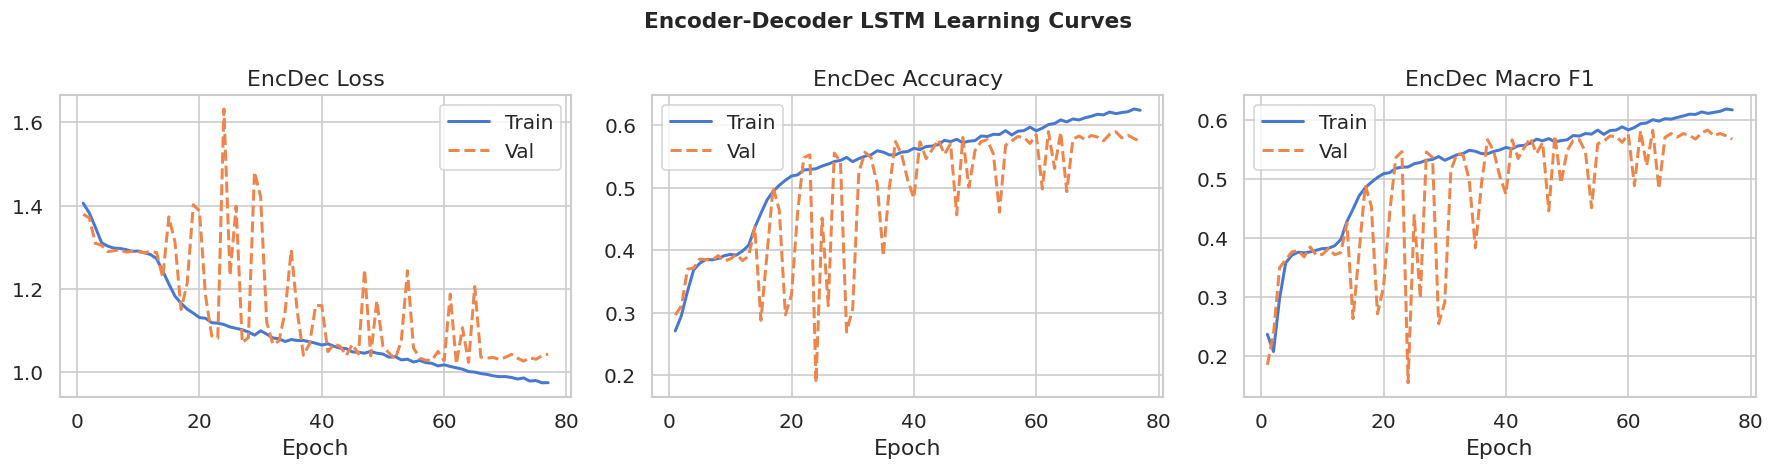

Timestep Importance via scaled_dot_product_attention scores:
------------------------------------------------
  Rank  1 | T10 | 0.1478
  Rank  2 | T 9 | 0.1239
  Rank  3 | T 8 | 0.1027
  Rank  4 | T 1 | 0.0951
  Rank  5 | T 7 | 0.0925
  Rank  6 | T 2 | 0.0898
  Rank  7 | T 6 | 0.0884
  Rank  8 | T 3 | 0.0873
  Rank  9 | T 5 | 0.0864
  Rank 10 | T 4 | 0.0862

Most important : T10
Least important: T4


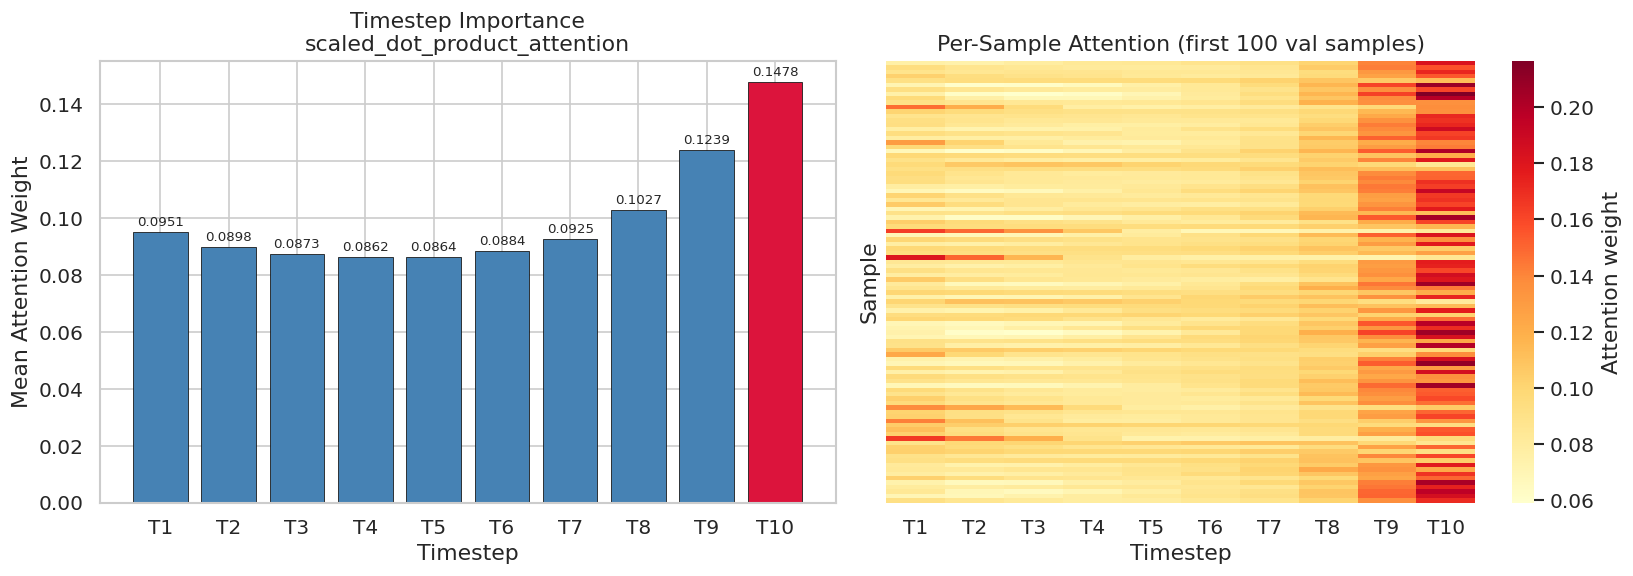

Test predictions: 10000

Prediction distribution:
  0 No Risk        : 3174 (31.7%)
  1 Low Risk       : 2421 (24.2%)
  2 Medium Risk    : 1976 (19.8%)
  3 Catastrophic   : 2429 (24.3%)

First 10 rows:
 sample_id  risk_level
     40000           1
     40001           2
     40002           3
     40003           0
     40004           1
     40005           3
     40006           0
     40007           1
     40008           3
     40009           0

✓ submission_encdec.csv saved!
  Model  → results/encdec_lstm_sdpa.pth
  Submit → results/submission_encdec.csv


In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 1 OF 3  —  Encoder-Decoder LSTM with scaled_dot_product_attention    ║
# ║  SELF-CONTAINED — run without any previous cells                            ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

# ── Imports ───────────────────────────────────────────────────────────────────
import os
import random
import warnings
import shutil
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from collections import Counter

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score,
    classification_report, confusion_matrix
)

import torch
import torch.nn as nn
import torch.nn.functional as F      # scaled_dot_product_attention lives here
from torch.utils.data import Dataset, DataLoader

# ── Seeds ─────────────────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

# ── Device ────────────────────────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')

# ── Plot style ────────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120, 'savefig.dpi': 150})

# ── Constants ─────────────────────────────────────────────────────────────────
NUM_TIMESTEPS = 10
NUM_FEATURES  = 25
NUM_CLASSES   = 4
CLASS_NAMES   = ['No Risk', 'Low Risk', 'Medium Risk', 'Catastrophic']
BATCH_SIZE    = 64
TEST_SIZE     = 0.20

# ══════════════════════════════════════════════════════════════════════════════
# USER SETTINGS
# ══════════════════════════════════════════════════════════════════════════════
TRAIN_PATH = 'train.txt'
TEST_PATH  = 'test.txt'
# ══════════════════════════════════════════════════════════════════════════════


# ── Data loading ──────────────────────────────────────────────────────────────
def load_dataset(path):
    with open(path, 'r') as fh:
        lines = [ln.strip() for ln in fh if ln.strip()]
    BLOCK      = NUM_TIMESTEPS + 1
    num_blocks = len(lines) // BLOCK
    print(f'Total lines: {len(lines)}  |  Blocks: {num_blocks}')
    X_list, y_list, skipped = [], [], 0
    for b in range(num_blocks):
        block = lines[b * BLOCK : (b + 1) * BLOCK]
        try:
            label = int(block[-1])
            assert 0 <= label < NUM_CLASSES
        except Exception:
            skipped += 1; continue
        ok, timesteps = True, []
        for t in range(NUM_TIMESTEPS):
            tokens = block[t].split(',')
            if len(tokens) < 2 + NUM_FEATURES:
                ok = False; break
            try:
                timesteps.append([float(v) for v in tokens[2 : 2 + NUM_FEATURES]])
            except ValueError:
                ok = False; break
        if not ok:
            skipped += 1; continue
        X_list.append(timesteps); y_list.append(label)
    X = np.array(X_list, dtype=np.float32)
    y = np.array(y_list, dtype=np.int64)
    print(f'Valid: {len(X_list)}  |  Skipped: {skipped}')
    return X, y


def load_test_dataset(path):
    with open(path, 'r') as fh:
        lines = [ln.strip() for ln in fh if ln.strip()]
    has_labels = (len(lines) > NUM_TIMESTEPS and
                  len(lines[NUM_TIMESTEPS].split(',')) == 1)
    BLOCK      = NUM_TIMESTEPS + (1 if has_labels else 0)
    num_blocks = len(lines) // BLOCK
    print(f'Test lines: {len(lines)}  |  Blocks: {num_blocks}  |  Labels detected: {has_labels}')
    X_list, sample_ids, skipped = [], [], 0
    for b in range(num_blocks):
        block = lines[b * BLOCK : (b + 1) * BLOCK][:NUM_TIMESTEPS]
        ok, timesteps, sid = True, [], None
        for t, row in enumerate(block):
            tokens = row.split(',')
            if len(tokens) < 2 + NUM_FEATURES:
                ok = False; break
            try:
                if t == 0: sid = int(tokens[0])
                timesteps.append([float(v) for v in tokens[2 : 2 + NUM_FEATURES]])
            except ValueError:
                ok = False; break
        if not ok:
            skipped += 1; continue
        X_list.append(timesteps); sample_ids.append(sid)
    X_test = np.array(X_list, dtype=np.float32)
    print(f'Test valid: {len(X_list)}  |  Skipped: {skipped}')
    return X_test, sample_ids


class SensorDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self): return len(self.y)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]


# ── Load data ─────────────────────────────────────────────────────────────────
X, y = load_dataset(TRAIN_PATH)
counts = Counter(y.tolist())
print(f'\nX: {X.shape}  y: {y.shape}')
for cls in range(NUM_CLASSES):
    n = counts.get(cls, 0)
    print(f'  {cls} {CLASS_NAMES[cls]:15s}: {n} ({100*n/len(y):.1f}%)')

X_test, test_sample_ids = load_test_dataset(TEST_PATH)
print(f'X_test: {X_test.shape}')

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=SEED, stratify=y
)
print(f'Train: {X_train.shape[0]}  |  Val: {X_val.shape[0]}')

train_loader = DataLoader(SensorDataset(X_train, y_train),
                          batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(SensorDataset(X_val,   y_val),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=0)


# ══════════════════════════════════════════════════════════════════════════════
# MODEL
# ══════════════════════════════════════════════════════════════════════════════

class Encoder(nn.Module):
    """Bidirectional LSTM — encodes all 10 timesteps."""
    def __init__(self, input_size=25, hidden_size=128,
                 num_layers=2, dropout=0.3):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers  = num_layers
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                            batch_first=True, bidirectional=True,
                            dropout=dropout if num_layers > 1 else 0.0)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        H, (h_n, c_n) = self.lstm(x)
        H = self.dropout(H)
        batch = x.size(0)
        h_n = h_n.view(self.num_layers, 2, batch, self.hidden_size)
        h_n = torch.cat([h_n[:, 0], h_n[:, 1]], dim=-1)
        c_n = c_n.view(self.num_layers, 2, batch, self.hidden_size)
        c_n = torch.cat([c_n[:, 0], c_n[:, 1]], dim=-1)
        return H, h_n, c_n


class EncDecAttentionClassifier(nn.Module):
    """
    Encoder-Decoder with F.scaled_dot_product_attention.

    F.scaled_dot_product_attention(query, key, value)
      - Computes softmax(Q·Kᵀ / sqrt(d)) · V in one built-in call
      - query : (batch, 1, D)   — decoder context vector (what we are looking for)
      - key   : (batch, T, D)   — encoder outputs       (what each timestep offers)
      - value : (batch, T, D)   — encoder outputs       (what we retrieve)

    To extract the per-timestep importance scores (alpha) we manually
    compute softmax(Q·Kᵀ / sqrt(d)) AFTER the forward pass for analysis.
    During training only F.scaled_dot_product_attention is used.
    """
    def __init__(self, input_size=25, hidden_size=128,
                 num_layers=2, num_classes=4, dropout=0.3):
        super().__init__()
        enc_out_dim = hidden_size * 2   # 256 — bidirectional

        self.encoder     = Encoder(input_size, hidden_size, num_layers, dropout)

        # Decoder: one-step LSTM to produce the context query vector
        self.dec_lstm    = nn.LSTM(enc_out_dim, enc_out_dim, num_layers,
                                   batch_first=True,
                                   dropout=dropout if num_layers > 1 else 0.0)
        self.start_token = nn.Parameter(torch.zeros(1, 1, enc_out_dim))

        self.classifier  = nn.Sequential(
            nn.Linear(enc_out_dim, 128),
            nn.BatchNorm1d(128),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64, num_classes),
        )

        self.enc_out_dim = enc_out_dim

    def forward(self, x, return_alpha=False):
        # ── Encode ────────────────────────────────────────────────────────────
        H, h_n, c_n = self.encoder(x)          # H: (batch, 10, 256)

        # ── Decode: one step to get context query ─────────────────────────────
        batch = x.size(0)
        start = self.start_token.expand(batch, 1, -1)   # (batch, 1, 256)
        _, (h_dec, _) = self.dec_lstm(start, (h_n, c_n))
        query = h_dec[-1].unsqueeze(1)                  # (batch, 1, 256)

        # ── Attention using PyTorch built-in function ─────────────────────────
        #
        #   F.scaled_dot_product_attention(query, key, value)
        #
        #   Internally computes:
        #     scores   = query · keyᵀ / sqrt(256)    (batch, 1, 10)
        #     alpha    = softmax(scores)              (batch, 1, 10)
        #     attended = alpha · value                (batch, 1, 256)
        #
        #   query : (batch, 1, 256)  — context vector, what we want to find
        #   key   : (batch, 10, 256) — encoder outputs, what each timestep offers
        #   value : (batch, 10, 256) — encoder outputs, what we retrieve
        #
        attended = F.scaled_dot_product_attention(
            query,    # Q
            H,        # K
            H,        # V  (K and V are the same — standard self/cross attention)
            dropout_p=0.0,
        )                                               # (batch, 1, 256)

        attended = attended.squeeze(1)                  # (batch, 256)

        # ── Classify ──────────────────────────────────────────────────────────
        logits = self.classifier(attended)              # (batch, 4)

        # ── Optionally compute alpha for interpretability ─────────────────────
        # F.scaled_dot_product_attention does not return alpha directly,
        # so we recompute the scores manually when needed (eval/analysis only)
        if return_alpha:
            scale  = self.enc_out_dim ** 0.5
            scores = torch.bmm(query, H.permute(0, 2, 1)) / scale  # (batch,1,10)
            alpha  = torch.softmax(scores, dim=-1).squeeze(1)       # (batch, 10)
            return logits, alpha

        return logits, None


# ── Instantiate ───────────────────────────────────────────────────────────────
encdec_model = EncDecAttentionClassifier().to(DEVICE)
total_p = sum(p.numel() for p in encdec_model.parameters())
print(f'\nTotal parameters: {total_p:,}')
print(encdec_model)

# ── Training setup ────────────────────────────────────────────────────────────
ENC_MAX_EPOCHS   = 100
ENC_LR           = 5e-4
ENC_WEIGHT_DECAY = 1e-4
ENC_ES_PATIENCE  = 15

enc_criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
enc_optimizer = torch.optim.AdamW(
    encdec_model.parameters(), lr=ENC_LR, weight_decay=ENC_WEIGHT_DECAY
)
enc_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    enc_optimizer, T_max=ENC_MAX_EPOCHS
)

# ── Training loop ─────────────────────────────────────────────────────────────
enc_history = {k: [] for k in
               ['train_loss','val_loss','train_acc','val_acc','train_f1','val_f1']}
best_val_loss_enc  = float('inf')
enc_patience_count = 0
best_enc_state     = None

for epoch in range(1, ENC_MAX_EPOCHS + 1):

    encdec_model.train()
    tr_loss_sum, tr_preds, tr_labels = 0.0, [], []
    for Xb, yb in train_loader:
        Xb, yb    = Xb.to(DEVICE), yb.to(DEVICE)
        logits, _ = encdec_model(Xb)                   # return_alpha=False during training
        loss      = enc_criterion(logits, yb)
        enc_optimizer.zero_grad(); loss.backward()
        nn.utils.clip_grad_norm_(encdec_model.parameters(), 1.0)
        enc_optimizer.step()
        tr_loss_sum += loss.item() * Xb.size(0)
        tr_preds.extend(logits.argmax(1).cpu().numpy())
        tr_labels.extend(yb.cpu().numpy())

    encdec_model.eval()
    vl_loss_sum, vl_preds, vl_labels = 0.0, [], []
    with torch.no_grad():
        for Xb, yb in val_loader:
            Xb, yb    = Xb.to(DEVICE), yb.to(DEVICE)
            logits, _ = encdec_model(Xb)
            loss      = enc_criterion(logits, yb)
            vl_loss_sum += loss.item() * Xb.size(0)
            vl_preds.extend(logits.argmax(1).cpu().numpy())
            vl_labels.extend(yb.cpu().numpy())

    enc_scheduler.step()

    tr_loss = tr_loss_sum / len(tr_labels)
    vl_loss = vl_loss_sum / len(vl_labels)
    tr_acc  = accuracy_score(tr_labels, tr_preds)
    vl_acc  = accuracy_score(vl_labels, vl_preds)
    tr_f1   = f1_score(tr_labels, tr_preds, average='macro', zero_division=0)
    vl_f1   = f1_score(vl_labels, vl_preds, average='macro', zero_division=0)

    for k, v in zip(enc_history, [tr_loss,vl_loss,tr_acc,vl_acc,tr_f1,vl_f1]):
        enc_history[k].append(v)

    if vl_loss < best_val_loss_enc:
        best_val_loss_enc  = vl_loss
        enc_patience_count = 0
        best_enc_state = {k: v.cpu().clone()
                          for k, v in encdec_model.state_dict().items()}
    else:
        enc_patience_count += 1

    if epoch % 10 == 0 or enc_patience_count >= ENC_ES_PATIENCE:
        print(f'Epoch {epoch:03d} | '
              f'Train loss {tr_loss:.4f} acc {tr_acc:.3f} f1 {tr_f1:.3f} | '
              f'Val   loss {vl_loss:.4f} acc {vl_acc:.3f} f1 {vl_f1:.3f}')

    if enc_patience_count >= ENC_ES_PATIENCE:
        print(f'\nEarly stopping at epoch {epoch}.'); break

encdec_model.load_state_dict({k: v.to(DEVICE) for k, v in best_enc_state.items()})
print('\nBest weights restored.')

encdec_model.eval()
final_preds, final_labels = [], []
with torch.no_grad():
    for Xb, yb in val_loader:
        logits, _ = encdec_model(Xb.to(DEVICE))
        final_preds.extend(logits.argmax(1).cpu().numpy())
        final_labels.extend(yb.numpy())

print('\n══ Encoder-Decoder + scaled_dot_product_attention ══')
print(f'  Accuracy : {accuracy_score(final_labels, final_preds):.4f}')
print(f'  Macro F1 : {f1_score(final_labels, final_preds, average="macro", zero_division=0):.4f}')
print(classification_report(final_labels, final_preds,
                             target_names=CLASS_NAMES, zero_division=0))

ep = range(1, len(enc_history['train_loss']) + 1)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (tr_k, vl_k), title in zip(
    axes,
    [('train_loss','val_loss'),('train_acc','val_acc'),('train_f1','val_f1')],
    ['Loss', 'Accuracy', 'Macro F1']
):
    ax.plot(ep, enc_history[tr_k], label='Train', linewidth=1.8)
    ax.plot(ep, enc_history[vl_k], label='Val',   linewidth=1.8, linestyle='--')
    ax.set_title(f'EncDec {title}'); ax.set_xlabel('Epoch'); ax.legend()
plt.suptitle('Encoder-Decoder LSTM Learning Curves', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('encdec_learning_curves.png', bbox_inches='tight')
plt.show()


# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 2 OF 3  —  Attention analysis                                        ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

# return_alpha=True triggers the manual score recomputation for interpretability
encdec_model.eval()
all_alphas = []

with torch.no_grad():
    for Xb, _ in val_loader:
        _, alpha = encdec_model(Xb.to(DEVICE), return_alpha=True)
        all_alphas.append(alpha.cpu().numpy())

all_alphas  = np.concatenate(all_alphas, axis=0)   # (N_val, 10)
mean_alphas = all_alphas.mean(axis=0)              # (10,)

print('Timestep Importance via scaled_dot_product_attention scores:')
print('-' * 48)
ranking = np.argsort(mean_alphas)[::-1]
for rank, idx in enumerate(ranking, 1):
    print(f'  Rank {rank:2d} | T{idx+1:2d} | {mean_alphas[idx]:.4f}')

print(f'\nMost important : T{ranking[0]+1}')
print(f'Least important: T{ranking[-1]+1}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
colors = ['crimson' if i == ranking[0] else 'steelblue' for i in range(NUM_TIMESTEPS)]
bars = ax.bar([f'T{t+1}' for t in range(NUM_TIMESTEPS)],
              mean_alphas, color=colors, edgecolor='k', linewidth=0.5)
ax.bar_label(bars, fmt='%.4f', padding=2, fontsize=8)
ax.set_title('Timestep Importance\nscaled_dot_product_attention')
ax.set_xlabel('Timestep'); ax.set_ylabel('Mean Attention Weight')

ax = axes[1]
sns.heatmap(all_alphas[:100], ax=ax, cmap='YlOrRd',
            xticklabels=[f'T{t+1}' for t in range(NUM_TIMESTEPS)],
            yticklabels=False, cbar_kws={'label': 'Attention weight'})
ax.set_title('Per-Sample Attention (first 100 val samples)')
ax.set_xlabel('Timestep'); ax.set_ylabel('Sample')

plt.tight_layout()
plt.savefig('encdec_attention_importance.png', bbox_inches='tight')
plt.show()


# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 3 OF 3  —  Submission                                                ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

encdec_model.eval()
encdec_test_ds     = SensorDataset(X_test, np.zeros(len(X_test), dtype=np.int64))
encdec_test_loader = DataLoader(encdec_test_ds, batch_size=BATCH_SIZE, shuffle=False)

encdec_test_preds = []
with torch.no_grad():
    for Xb, _ in encdec_test_loader:
        logits, _ = encdec_model(Xb.to(DEVICE))
        encdec_test_preds.extend(logits.argmax(1).cpu().numpy())

print(f'Test predictions: {len(encdec_test_preds)}')

pred_counts = Counter(encdec_test_preds)
print('\nPrediction distribution:')
for cls in range(NUM_CLASSES):
    n = pred_counts.get(cls, 0)
    print(f'  {cls} {CLASS_NAMES[cls]:15s}: {n} ({100*n/max(len(encdec_test_preds),1):.1f}%)')

encdec_submission_df = pd.DataFrame({
    'sample_id'  : test_sample_ids,
    'risk_level' : encdec_test_preds
}).sort_values('sample_id').reset_index(drop=True)

print('\nFirst 10 rows:')
print(encdec_submission_df.head(10).to_string(index=False))

encdec_submission_df.to_csv('submission_encdec.csv', index=False)
print('\n✓ submission_encdec.csv saved!')

os.makedirs('results', exist_ok=True)
torch.save(encdec_model.state_dict(), 'results/encdec_lstm_sdpa.pth')
shutil.copy('submission_encdec.csv', 'results/submission_encdec.csv')
print('  Model  → results/encdec_lstm_sdpa.pth')
print('  Submit → results/submission_encdec.csv')

Final test accuracy is calculated on Kaggle using the submissions.csv file created in this notebook